In [57]:
import os

NOTEBOOK = os.getcwd()

PROJECT = os.path.dirname(NOTEBOOK)

DATA = os.path.join(PROJECT, "Data")
MASKED_DATA = os.path.join(PROJECT, "Masked_Data")
MASTER_DATASET = os.path.join(PROJECT, "Master_dataset")
RESULTS = os.path.join(PROJECT, "Results")
OUTPUT = os.path.join(PROJECT, "OUTPUT")

In [34]:
# ============================================================
# CREATE PIXEL AREA GRID (Run Only Once)
# ============================================================

import os
import numpy as np
import rasterio
from pyproj import Transformer, Geod

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

DATA = os.path.join(PROJECT, "Data")

OUTPUT = os.path.join(PROJECT, "OUTPUT")

PIXEL_AREA_FILE = os.path.join(PROJECT, "pixel_area_grid.npy")

# ============================================================
# FIND ONE TIFF FILE
# ============================================================

sample_file = None

for month in [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]:
    folder = os.path.join(DATA, month)

    if os.path.exists(folder):

        files = sorted(
            [f for f in os.listdir(folder) if f.endswith(".tif")]
        )

        if len(files) > 0:
            sample_file = os.path.join(folder, files[0])
            break

if sample_file is None:
    raise Exception("No TIFF file found.")

print("Using:", sample_file)

# ============================================================
# OPEN TIFF
# ============================================================

with rasterio.open(sample_file) as src:

    transform = src.transform
    crs = src.crs
    height = src.height
    width = src.width

print("Image Size :", height, "x", width)
print("CRS :", crs)

# ============================================================
# INITIALIZE
# ============================================================

transformer = Transformer.from_crs(
    crs,
    "EPSG:4326",
    always_xy=True
)

geod = Geod(ellps="WGS84")

pixel_area = np.zeros((height, width), dtype=np.float64)

print("\nCalculating Pixel Areas...")

# ============================================================
# LOOP THROUGH EVERY PIXEL
# ============================================================

for row in range(height):

    if row % 25 == 0:
        print(f"Row {row}/{height}")

    for col in range(width):

        x1, y1 = rasterio.transform.xy(transform, row, col, offset="ul")
        x2, y2 = rasterio.transform.xy(transform, row, col, offset="ur")
        x3, y3 = rasterio.transform.xy(transform, row, col, offset="lr")
        x4, y4 = rasterio.transform.xy(transform, row, col, offset="ll")

        lon, lat = transformer.transform(
            [x1, x2, x3, x4],
            [y1, y2, y3, y4]
        )

        area, _ = geod.polygon_area_perimeter(lon, lat)

        pixel_area[row, col] = abs(area) / 1e6   # km²

# ============================================================
# SAVE
# ============================================================

np.save(
    PIXEL_AREA_FILE,
    pixel_area
)

print("\n===================================")
print("Pixel Area Grid Saved Successfully")
print(PIXEL_AREA_FILE)

print("\nMinimum Pixel Area :", pixel_area.min())
print("Maximum Pixel Area :", pixel_area.max())
print("Mean Pixel Area    :", pixel_area.mean())

Using: C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Data\March\N_200003_extent_v4.0.tif
Image Size : 448 x 304
CRS : EPSG:3411

Calculating Pixel Areas...
Row 0/448
Row 25/448
Row 50/448
Row 75/448
Row 100/448
Row 125/448
Row 150/448
Row 175/448
Row 200/448
Row 225/448
Row 250/448
Row 275/448
Row 300/448
Row 325/448
Row 350/448
Row 375/448
Row 400/448
Row 425/448

Pixel Area Grid Saved Successfully
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\pixel_area_grid.npy

Minimum Pixel Area : 382.6425554984436
Maximum Pixel Area : 664.421195140625
Mean Pixel Area    : 555.5172977621352


In [75]:
# ============================================================
# ARCTIC SEA ICE MASTER DATASET (60°N–90°N)
# Uses Geodesic Pixel Area
# ============================================================

import os
import numpy as np
import pandas as pd
import rasterio

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

DATA = os.path.join(PROJECT, "Data")

MASTER_DATASET = os.path.join(PROJECT, "Master_Dataset")

LATITUDE_MASK = os.path.join(PROJECT, "latitude_mask.npy")

PIXEL_AREA = os.path.join(PROJECT, "pixel_area_grid.npy")

os.makedirs(MASTER_DATASET, exist_ok=True)

# ============================================================
# LOAD SUPPORT FILES
# ============================================================

latitude_mask = np.load(LATITUDE_MASK)

pixel_area = np.load(PIXEL_AREA)

print("Latitude Mask :", latitude_mask.shape)

print("Pixel Area Grid :", pixel_area.shape)

# ============================================================
# MONTHS
# ============================================================

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

results = []

# ============================================================
# PROCESS ALL IMAGES
# ============================================================

for month in months:

    folder = os.path.join(DATA, month)

    files = sorted(
        [f for f in os.listdir(folder)
         if f.endswith(".tif")]
    )

    print(f"\nProcessing {month}")

    for file in files:

        year = int(file[2:6])

        filepath = os.path.join(folder, file)

        with rasterio.open(filepath) as src:

            raster = src.read(1)

        # ====================================================
        # ONLY 60°N–90°N
        # ====================================================

        raster = np.where(
            latitude_mask,
            raster,
            255
        )

        # ====================================================
        # PIXEL COUNTS
        # ====================================================

        sea_ice_pixels = np.sum(raster == 1)

        ocean_pixels = np.sum(raster == 0)

        land_pixels = np.sum(raster == 254)

        coast_pixels = np.sum(raster == 253)

        ocean_plus_ice = sea_ice_pixels + ocean_pixels

        # ====================================================
        # TRUE SEA ICE AREA (km²)
        # ====================================================

        sea_ice_area = np.sum(
            pixel_area[raster == 1]
        )

        # ====================================================
        # MILLION km²
        # ====================================================

        sea_ice_area_million = sea_ice_area / 1e6

        # ====================================================
        # SEA ICE %
        # ====================================================

        if ocean_plus_ice > 0:

            sea_ice_percent = (
                sea_ice_pixels
                /
                ocean_plus_ice
            ) * 100

        else:

            sea_ice_percent = np.nan

        # ====================================================
        # SAVE
        # ====================================================

        results.append([

            year,

            month,

            sea_ice_pixels,

            ocean_pixels,

            ocean_plus_ice,

            land_pixels,

            coast_pixels,

            sea_ice_area,

            sea_ice_area_million,

            sea_ice_percent

        ])

        print(year, "Done")

# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(

    results,

    columns=[

        "Year",

        "Month",

        "Sea Ice Pixels",

        "Ocean Pixels",

        "Ocean + Ice Pixels",

        "Land Pixels",

        "Coast Pixels",

        "Sea Ice Area (km²)",

        "Sea Ice Area (Million km²)",

        "Sea Ice (%)"

    ]

)

# ============================================================
# MONTH ORDER
# ============================================================

month_order = {

    "March":1,
    "April":2,
    "May":3,
    "June":4,
    "July":5,
    "August":6,
    "September":7

}

df["Month_Order"] = df["Month"].map(month_order)

df = df.sort_values(

    ["Year","Month_Order"]

).drop(

    columns="Month_Order"

)

# ============================================================
# SAVE
# ============================================================

excel = os.path.join(

    MASTER_DATASET,

    "Sea_Ice_Master_Dataset.xlsx"

)

csv = os.path.join(

    MASTER_DATASET,

    "Sea_Ice_Master_Dataset.csv"

)

df.to_excel(

    excel,

    index=False

)

df.to_csv(

    csv,

    index=False

)

print("\n==========================================")

print("MASTER DATASET CREATED SUCCESSFULLY")

print(excel)

print(csv)

Latitude Mask : (448, 304)
Pixel Area Grid : (448, 304)

Processing March
2000 Done
2001 Done
2002 Done
2003 Done
2004 Done
2005 Done
2006 Done
2007 Done
2008 Done
2009 Done
2010 Done
2011 Done
2012 Done
2013 Done
2014 Done
2015 Done
2016 Done
2017 Done
2018 Done
2019 Done
2020 Done
2021 Done
2022 Done
2023 Done
2024 Done
2025 Done
2026 Done

Processing April
2000 Done
2001 Done
2002 Done
2003 Done
2004 Done
2005 Done
2006 Done
2007 Done


C:\Users\ACER\AppData\Local\Temp\ipykernel_12984\2457817124.py:78: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raster = src.read(1)


2008 Done
2009 Done
2010 Done
2011 Done
2012 Done
2013 Done
2014 Done
2015 Done
2016 Done
2017 Done
2018 Done
2019 Done
2020 Done
2021 Done
2022 Done
2023 Done
2024 Done
2025 Done
2026 Done

Processing May
2000 Done
2001 Done
2002 Done
2003 Done
2004 Done
2005 Done
2006 Done
2007 Done
2008 Done
2009 Done
2010 Done
2011 Done
2012 Done
2013 Done
2014 Done
2015 Done
2016 Done
2017 Done
2018 Done
2019 Done
2020 Done
2021 Done
2022 Done
2023 Done
2024 Done
2025 Done
2026 Done

Processing June
2000 Done
2001 Done
2002 Done
2003 Done
2004 Done
2005 Done
2006 Done
2007 Done
2008 Done
2009 Done
2010 Done
2011 Done
2012 Done
2013 Done
2014 Done
2015 Done
2016 Done
2017 Done
2018 Done
2019 Done
2020 Done
2021 Done
2022 Done
2023 Done
2024 Done
2025 Done
2026 Done

Processing July
2000 Done
2001 Done
2002 Done
2003 Done
2004 Done
2005 Done
2006 Done
2007 Done
2008 Done
2009 Done
2010 Done
2011 Done
2012 Done
2013 Done
2014 Done
2015 Done
2016 Done
2017 Done
2018 Done
2019 Done
2020 Done
2021 Done


In [76]:
print(df.shape)

(186, 10)


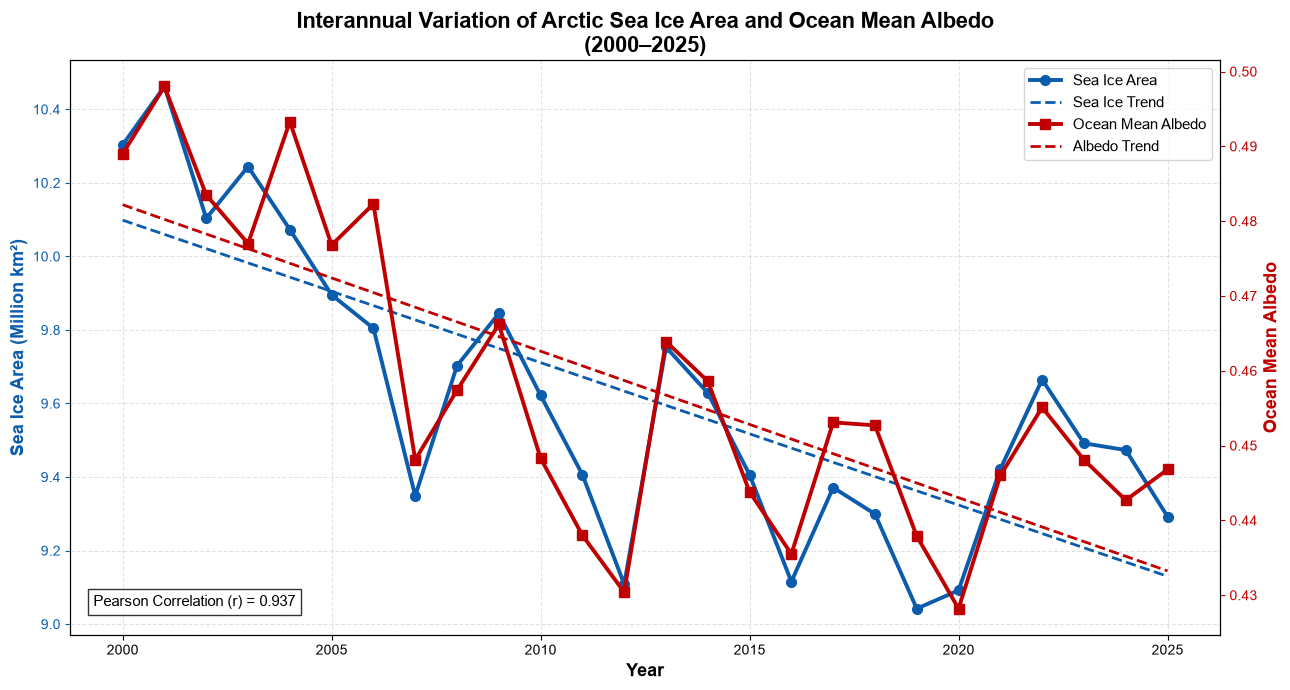


Correlation (r): 0.937
Figure Saved Successfully
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\SeaIce_Albedo_Interannual_Variation.png


In [36]:
# ============================================================
# INTERANNUAL VARIATION OF
# SEA ICE AREA vs OCEAN MEAN ALBEDO
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

SEAICE_FILE = os.path.join(
    PROJECT,
    "Master_Dataset",
    "Sea_Ice_Master_Dataset.xlsx"
)

# Change this path only
ALBEDO_FILE = r"C:\Users\ACER\OneDrive\Desktop\ISRO\snow_2\Master_dataset\Albedo_Statistics_2000_2026 (1).xlsx"
# ALBEDO_FILE = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Albedo_Statistics_2000_2026 (1).xlsx"

OUTPUT = os.path.join(
    PROJECT,
    "OUTPUT"
)

os.makedirs(OUTPUT, exist_ok=True)

# ============================================================
# READ SEA ICE
# ============================================================

seaice = pd.read_excel(SEAICE_FILE)

seaice_year = (
    seaice
    .groupby("Year")["Sea Ice Area (Million km²)"]
    .mean()
    .reset_index()
)

# ============================================================
# READ ALBEDO
# ============================================================

albedo = pd.read_excel(
    ALBEDO_FILE,
    sheet_name="Yearly_albedo_statistics"
)

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

albedo = albedo[
    [
        "Year",
        "Ocean Mean Albedo"
    ]
]

# ============================================================
# MERGE
# ============================================================

df = pd.merge(
    seaice_year,
    albedo,
    on="Year"
)

# ============================================================
# TREND LINES
# ============================================================

x = df["Year"]

# Sea Ice

sea_fit = np.polyfit(
    x,
    df["Sea Ice Area (Million km²)"],
    1
)

sea_trend = np.poly1d(sea_fit)(x)

# Albedo

alb_fit = np.polyfit(
    x,
    df["Ocean Mean Albedo"],
    1
)

alb_trend = np.poly1d(alb_fit)(x)

# ============================================================
# CORRELATION
# ============================================================

corr = df["Sea Ice Area (Million km²)"].corr(
    df["Ocean Mean Albedo"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(13,7))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(

    x,

    df["Sea Ice Area (Million km²)"],

    color="#0B5CAD",

    marker="o",

    markersize=7,

    linewidth=2.8,

    label="Sea Ice Area"

)

ax1.plot(

    x,

    sea_trend,

    "--",

    color="#0B5CAD",

    linewidth=2,

    label="Sea Ice Trend"

)

ax1.set_xlabel(

    "Year",

    fontsize=13,

    fontweight="bold"

)

ax1.set_ylabel(

    "Sea Ice Area (Million km²)",

    fontsize=13,

    color="#0B5CAD",

    fontweight="bold"

)

ax1.tick_params(

    axis="y",

    colors="#0B5CAD"

)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(

    x,

    df["Ocean Mean Albedo"],

    color="#C00000",

    marker="s",

    markersize=7,

    linewidth=2.8,

    label="Ocean Mean Albedo"

)

ax2.plot(

    x,

    alb_trend,

    "--",

    color="#C00000",

    linewidth=2,

    label="Albedo Trend"

)

ax2.set_ylabel(

    "Ocean Mean Albedo",

    fontsize=13,

    color="#C00000",

    fontweight="bold"

)

ax2.tick_params(

    axis="y",

    colors="#C00000"

)

# ============================================================
# GRID
# ============================================================

ax1.grid(

    True,

    linestyle="--",

    alpha=0.35

)

# ============================================================
# CORRELATION TEXT
# ============================================================

ax1.text(

    0.02,

    0.05,

    f"Pearson Correlation (r) = {corr:.3f}",

    transform=ax1.transAxes,

    fontsize=11,

    bbox=dict(

        facecolor="white",

        alpha=0.8

    )

)

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()

lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(

    lines1 + lines2,

    labels1 + labels2,

    loc="upper right",

    fontsize=11,

    frameon=True

)

# ============================================================
# TITLE
# ============================================================

plt.title(

    "Interannual Variation of Arctic Sea Ice Area and Ocean Mean Albedo\n(2000–2025)",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

save = os.path.join(

    OUTPUT,

    "SeaIce_Albedo_Interannual_Variation.png"

)

plt.savefig(

    save,

    dpi=600,

    bbox_inches="tight"

)

plt.show()

print("\n======================================")

print("Correlation (r):", round(corr,3))

print("Figure Saved Successfully")

print(save)

# deviation

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

SEAICE_FILE = os.path.join(
    PROJECT,
    "Master_Dataset",
    "Sea_Ice_Master_Dataset.xlsx"
)

ALBEDO_FILE = r"C:\Users\ACER\OneDrive\Desktop\ISRO\snow_2\Master_dataset\Albedo_Statistics_2000_2026 (1).xlsx"

OUTPUT = os.path.join(PROJECT, "OUTPUT")

os.makedirs(OUTPUT, exist_ok=True)

# ============================================================
# SEA ICE
# ============================================================

seaice = pd.read_excel(SEAICE_FILE)

seaice_year = (
    seaice
    .groupby("Year")["Sea Ice Area (Million km²)"]
    .mean()
    .reset_index()
)

# ============================================================
# ALBEDO
# ============================================================

albedo = pd.read_excel(
    ALBEDO_FILE,
    sheet_name="Yearly_albedo_statistics"
)

albedo = albedo[
    [
        "Year",
        "Ocean Mean Albedo"
    ]
]

# ============================================================
# MERGE
# ============================================================

df = pd.merge(
    seaice_year,
    albedo,
    on="Year"
)

In [38]:
# ============================================================
# LONG TERM MEAN
# ============================================================

mean_seaice = df["Sea Ice Area (Million km²)"].mean()

mean_albedo = df["Ocean Mean Albedo"].mean()

print("Mean Sea Ice :", mean_seaice)

print("Mean Albedo :", mean_albedo)

Mean Sea Ice : 9.614268622882898
Mean Albedo : 0.4577192307692307


In [39]:
# ============================================================
# ANOMALIES (DEVIATIONS)
# ============================================================

df["Sea Ice Deviation"] = (

    df["Sea Ice Area (Million km²)"]

    -

    mean_seaice

)

df["Albedo Deviation"] = (

    df["Ocean Mean Albedo"]

    -

    mean_albedo

)

print(df.head())

   Year  Sea Ice Area (Million km²)  Ocean Mean Albedo  Sea Ice Deviation  \
0  2000                   10.303357             0.4890           0.689088   
1  2001                   10.462073             0.4980           0.847805   
2  2002                   10.103425             0.4835           0.489156   
3  2003                   10.244253             0.4770           0.629985   
4  2004                   10.073042             0.4933           0.458774   

   Albedo Deviation  
0          0.031281  
1          0.040281  
2          0.025781  
3          0.019281  
4          0.035581  


In [40]:
x = df["Year"]

sea_fit = np.polyfit(
    x,
    df["Sea Ice Deviation"],
    1
)

sea_trend = np.poly1d(sea_fit)(x)

alb_fit = np.polyfit(
    x,
    df["Albedo Deviation"],
    1
)

alb_trend = np.poly1d(alb_fit)(x)

In [41]:
corr = df["Sea Ice Deviation"].corr(
    df["Albedo Deviation"]
)

print(corr)

0.9372082475150819


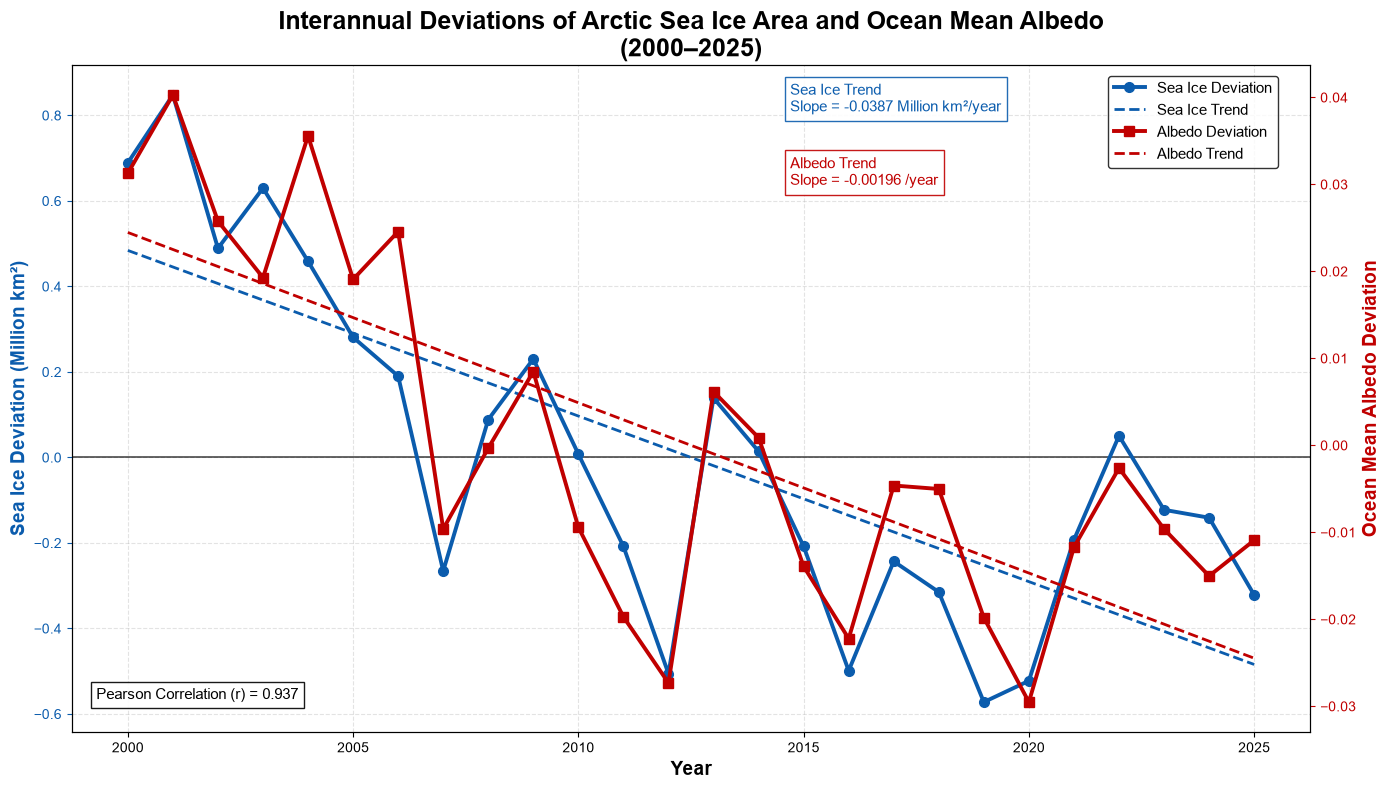

Mean Sea Ice Area : 9.614 Million km²
Mean Ocean Albedo : 0.4577
Sea Ice Trend Slope : -0.0387 Million km²/year
Albedo Trend Slope : -0.00196 /year
Pearson Correlation : 0.937
Saved : C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\OUTPUT\SeaIce_Albedo_Deviation.png


In [42]:
# ============================================================
# INTERANNUAL ANOMALY
# Sea Ice Area Deviation vs Ocean Mean Albedo Deviation
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

SEAICE_FILE = os.path.join(
    PROJECT,
    "Master_Dataset",
    "Sea_Ice_Master_Dataset.xlsx"
)

ALBEDO_FILE = r"C:\Users\ACER\OneDrive\Desktop\ISRO\snow_2\Master_dataset\Albedo_Statistics_2000_2026 (1).xlsx"

OUTPUT = os.path.join(
    PROJECT,
    "OUTPUT"
)

os.makedirs(OUTPUT, exist_ok=True)

# ============================================================
# READ SEA ICE
# ============================================================

seaice = pd.read_excel(SEAICE_FILE)

seaice_year = (
    seaice
    .groupby("Year")["Sea Ice Area (Million km²)"]
    .mean()
    .reset_index()
)

# ============================================================
# READ ALBEDO
# ============================================================

albedo = pd.read_excel(
    ALBEDO_FILE,
    sheet_name="Yearly_albedo_statistics"
)

albedo = albedo[
    [
        "Year",
        "Ocean Mean Albedo"
    ]
]

# ============================================================
# MERGE
# ============================================================

df = pd.merge(
    seaice_year,
    albedo,
    on="Year"
)

# ============================================================
# LONG TERM MEAN
# ============================================================

mean_seaice = df["Sea Ice Area (Million km²)"].mean()

mean_albedo = df["Ocean Mean Albedo"].mean()

# ============================================================
# DEVIATIONS (ANOMALIES)
# ============================================================

df["Sea Ice Deviation"] = (
    df["Sea Ice Area (Million km²)"] - mean_seaice
)

df["Albedo Deviation"] = (
    df["Ocean Mean Albedo"] - mean_albedo
)

# ============================================================
# CORRELATION
# ============================================================

corr = df["Sea Ice Deviation"].corr(
    df["Albedo Deviation"]
)

# ============================================================
# TREND LINES
# ============================================================

x = df["Year"]

sea_fit = np.polyfit(
    x,
    df["Sea Ice Deviation"],
    1
)

sea_trend = np.poly1d(sea_fit)(x)

alb_fit = np.polyfit(
    x,
    df["Albedo Deviation"],
    1
)

alb_trend = np.poly1d(alb_fit)(x)

sea_slope = sea_fit[0]
alb_slope = alb_fit[0]

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(14,8))

# ------------------------------------------------------------
# Zero Reference Line
# ------------------------------------------------------------

ax1.axhline(
    0,
    color="black",
    linewidth=1.2,
    linestyle="-",
    alpha=0.7
)

# ------------------------------------------------------------
# Sea Ice
# ------------------------------------------------------------

ax1.plot(
    x,
    df["Sea Ice Deviation"],
    color="#0B5CAD",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_trend,
    "--",
    color="#0B5CAD",
    linewidth=2,
    label="Sea Ice Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (Million km²)",
    fontsize=14,
    color="#0B5CAD",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#0B5CAD"
)

# ------------------------------------------------------------
# Albedo
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation"],
    color="#C00000",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_trend,
    "--",
    color="#C00000",
    linewidth=2,
    label="Albedo Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation",
    fontsize=14,
    color="#C00000",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C00000"
)

# ------------------------------------------------------------
# X-axis
# ------------------------------------------------------------

ax1.set_xlabel(
    "Year",
    fontsize=14,
    fontweight="bold"
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ------------------------------------------------------------
# Correlation
# ------------------------------------------------------------

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.9
    )
)

# ------------------------------------------------------------
# Slope Annotation
# ------------------------------------------------------------

ax1.text(
    0.58,
    0.93,
    f"Sea Ice Trend\nSlope = {sea_slope:.4f} Million km²/year",
    color="#0B5CAD",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        alpha=0.9,
        edgecolor="#0B5CAD"
    )
)

ax1.text(
    0.58,
    0.82,
    f"Albedo Trend\nSlope = {alb_slope:.5f} /year",
    color="#C00000",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        alpha=0.9,
        edgecolor="#C00000"
    )
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()

lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     fontsize=11,
#     loc="upper left",
#     frameon=True
# )

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.995),
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

plt.tight_layout(rect=[0, 0, 0.82, 1])

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    "Interannual Deviations of Arctic Sea Ice Area and Ocean Mean Albedo\n(2000–2025)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

save = os.path.join(
    OUTPUT,
    "SeaIce_Albedo_Deviation.png"
)

plt.savefig(
    save,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("="*60)
print("Mean Sea Ice Area :", round(mean_seaice,3), "Million km²")
print("Mean Ocean Albedo :", round(mean_albedo,4))
print("Sea Ice Trend Slope :", round(sea_slope,4), "Million km²/year")
print("Albedo Trend Slope :", round(alb_slope,5), "/year")
print("Pearson Correlation :", round(corr,3))
print("="*60)
print("Saved :", save)

In [43]:
import os
import pandas as pd

# ============================================================
# PATHS
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

MASTER_DATASET = os.path.join(
    PROJECT,
    "Master_Dataset",
    "Sea_Ice_Master_Dataset.xlsx"
)

OUTPUT_FOLDER = os.path.join(
    PROJECT,
    "Master_Dataset"
)

# ============================================================
# READ MASTER DATASET
# ============================================================

df = pd.read_excel(MASTER_DATASET)

# ============================================================
# PIVOT TABLE
# ============================================================

pivot = df.pivot_table(
    index="Year",
    columns="Month",
    values="Sea Ice Area (Million km²)"
)

# ============================================================
# MONTH ORDER
# ============================================================

month_order = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

pivot = pivot[month_order]

# ============================================================
# YEARLY STATISTICS
# ============================================================

pivot["Yearly Mean"] = pivot.mean(axis=1)

pivot["Minimum"] = pivot.min(axis=1)

pivot["Maximum"] = pivot.max(axis=1)

pivot["Standard Deviation"] = pivot[month_order].std(axis=1)

# ============================================================
# ROUND VALUES
# ============================================================

pivot = pivot.round(3)

# ============================================================
# SAVE
# ============================================================

excel_file = os.path.join(
    OUTPUT_FOLDER,
    "Yearly_Average_Sea_Ice.xlsx"
)

csv_file = os.path.join(
    OUTPUT_FOLDER,
    "Yearly_Average_Sea_Ice.csv"
)

pivot.to_excel(excel_file)

pivot.to_csv(csv_file)

print("="*60)
print("Yearly Average Sea Ice Saved Successfully")
print(excel_file)
print(csv_file)
print("="*60)

print(pivot.head())

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\ACER\\OneDrive\\Desktop\\ISRO\\Snow_2\\Master_Dataset\\Yearly_Average_Sea_Ice.xlsx'

In [ ]:
excel = pd.ExcelFile(r"C:\Users\ACER\OneDrive\Desktop\ISRO\snow_2\Master_dataset\Albedo_Statistics_2000_2026 (1).xlsx")
print(excel.sheet_names)

['Monthly_albedo_statistics', 'Monthly_Pixels_Min_Max_Albedos', 'Yearly_Pixels_Min_Max_Albedos', 'Yearly_albedo_statistics']


In [ ]:
print(seaice.columns.tolist())
print(albedo.columns.tolist())

['Year', 'Month', 'Sea Ice Pixels', 'Ocean Pixels', 'Ocean + Ice Pixels', 'Land Pixels', 'Coast Pixels', 'Sea Ice Area (km²)', 'Sea Ice Area (Million km²)', 'Sea Ice (%)']
['Year', 'Ocean Mean Albedo']


In [ ]:
print(df.head())

   Year  Month  Sea Ice Pixels  Ocean Pixels  Ocean + Ice Pixels  Land Pixels  \
0  2000  March           20136          6750               26886        25776   
1  2000  April           20047          6839               26886        25776   
2  2000    May           19118          7768               26886        25776   
3  2000   June           17405          9481               26886        25776   
4  2000   July           14738         12148               26886        25776   

   Coast Pixels  Sea Ice Area (km²)  Sea Ice Area (Million km²)  Sea Ice (%)  
0          2850        1.282731e+07                   12.827307    74.893997  
1          2850        1.278075e+07                   12.780754    74.562970  
2          2850        1.221732e+07                   12.217321    71.107640  
3          2850        1.116819e+07                   11.168194    64.736294  
4          2850        9.517845e+06                    9.517845    54.816633  


# MK Test & sen-slope Test

In [ ]:
import pandas as pd
import pymannkendall as mk

In [ ]:
!pip install pymannkendall

In [ ]:
import os

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

SEAICE_FILE = os.path.join(
    PROJECT,
    "Master_dataset",
    "Yearly_Average_Sea_Ice.xlsx"
)

seaice = pd.read_excel(SEAICE_FILE)

print(seaice.head())

   Year   March   April     May    June   July  August  September  \
0  2000  12.827  12.781  12.217  11.168  9.518   7.251      6.361   
1  2001  13.032  12.991  12.403  11.224  9.281   7.526      6.778   
2  2002  12.957  12.663  12.112  11.088  9.358   6.565      5.981   
3  2003  12.960  12.805  12.157  11.286  9.386   6.931      6.184   
4  2004  12.914  12.615  11.778  10.991  9.297   6.834      6.082   

   Yearly Mean  Minimum  Maximum  Standard Deviation  
0       10.303    6.361   12.827               2.658  
1       10.462    6.778   13.032               2.612  
2       10.103    5.981   12.957               2.880  
3       10.244    6.184   12.960               2.795  
4       10.073    6.082   12.914               2.748  


In [ ]:
seaice_series = seaice["Yearly Mean"]

In [ ]:
result = mk.original_test(seaice_series)

In [ ]:
print("="*50)
print("MANN-KENDALL TEST")
print("="*50)

print("Trend              :", result.trend)
print("H (Significant?)   :", result.h)
print("P-value            :", result.p)
print("Z statistic        :", result.z)
print("Tau                :", result.Tau)
print("S statistic        :", result.s)
print("Variance(S)        :", result.var_s)
print("Sen's Slope        :", result.slope)
print("Intercept          :", result.intercept)

MANN-KENDALL TEST
Trend              : decreasing
H (Significant?)   : True
P-value            : 0.0012293849189448647
Z statistic        : -3.231973417884659
Tau                : -0.4444444444444444
S statistic        : -156.0
Variance(S)        : 2300.0
Sen's Slope        : -0.03688888888888878
Intercept          : 10.101555555555555


| Output          | Meaning                                                                        |
| --------------- | ------------------------------------------------------------------------------ |
| **Trend**       | Increasing, decreasing, or no trend                                            |
| **H**           | `True` = statistically significant, `False` = not significant                  |
| **P-value**     | If < 0.05, the trend is statistically significant                              |
| **Z statistic** | Indicates the strength and direction of the trend                              |
| **Tau**         | Kendall's correlation coefficient (ranges from -1 to +1)                       |
| **S statistic** | The Mann–Kendall test statistic (positive = increasing, negative = decreasing) |
| **Variance(S)** | Used internally to calculate the Z statistic                                   |
| **Sen's Slope** | Estimated rate of change per year (we'll discuss this next)                    |
| **Intercept**   | Intercept of the Sen's line                                                    |


In [ ]:
import pymannkendall as mk

# Sea Ice
sea_result = mk.original_test(df["Sea Ice Deviation (%)"])

# Albedo
alb_result = mk.original_test(df["Albedo Deviation (%)"])

KeyError: 'Sea Ice Deviation (%)'

In [ ]:
sea_result.slope
sea_result.intercept
sea_result.p
sea_result.Tau

alb_result.slope
alb_result.intercept
alb_result.p
alb_result.Tau

np.float64(-0.5415384615384615)

In [ ]:
x_index = np.arange(len(df))

sea_sen = (
    sea_result.intercept
    +
    sea_result.slope * x_index
)

alb_sen = (
    alb_result.intercept
    +
    alb_result.slope * x_index
)

In [ ]:
ax1.plot(
    df["Year"],
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Sea Ice Deviation"
)

ax1.plot(
    df["Year"],
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

In [ ]:
ax2.plot(
    df["Year"],
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.5,
    markersize=6,
    label="Ocean Mean Albedo Deviation"
)

ax2.plot(
    df["Year"],
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

In [ ]:
ax1.text(
    0.02,
    0.95,
    (
        "Sea Ice\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.4f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"p-value : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0"
    )
)

Text(0.02, 0.95, "Sea Ice\nTrend : decreasing\nSen's Slope : -0.4364 %/year\nTau : -0.560\np-value : 0.0001")

In [ ]:
ax2.text(
    0.98,
    0.95,
    (
        "Ocean Albedo\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.4f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"p-value : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828"
    )
)

Text(0.98, 0.95, "Ocean Albedo\nTrend : decreasing\nSen's Slope : -0.4206 %/year\nTau : -0.542\np-value : 0.0001")

In [ ]:
corr = df["Sea Ice Deviation (%)"].corr(
    df["Albedo Deviation (%)"]
)

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

Text(0.02, 0.05, 'Pearson Correlation (r) = 0.937')

In [ ]:
ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

Text(0.5, 1.0, "Interannual Percentage Deviations of Arctic Sea Ice Area\nand Ocean Mean Albedo with Mann–Kendall Test and Sen's Slope (2000–2025)")

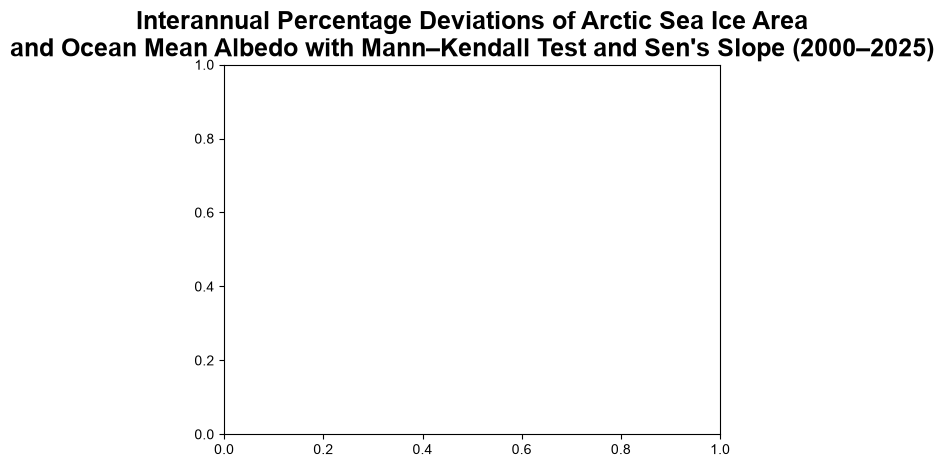

In [ ]:
plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo with Mann–Kendall Test and Sen's Slope (2000–2025)",
    fontsize=18,
    fontweight="bold"
)

In [ ]:
print(df.head())
print()
print(df.columns.tolist())
print()
print(df.shape)

   Year  Yearly Mean  Sea Ice Deviation (%)  Ocean Mean Albedo  \
0  2000       10.303               7.163631             0.4890   
1  2001       10.462               8.817423             0.4980   
2  2002       10.103               5.083390             0.4835   
3  2003       10.244               6.549960             0.4770   
4  2004       10.073               4.771353             0.4933   

   Albedo Deviation (%)  
0              6.834052  
1              8.800323  
2              5.632442  
3              4.212357  
4              7.773492  

['Year', 'Yearly Mean', 'Sea Ice Deviation (%)', 'Ocean Mean Albedo', 'Albedo Deviation (%)']

(26, 5)


In [ ]:
print(df["Sea Ice Deviation (%)"].head())
print(df["Albedo Deviation (%)"].head())

0    7.163631
1    8.817423
2    5.083390
3    6.549960
4    4.771353
Name: Sea Ice Deviation (%), dtype: float64
0    6.834052
1    8.800323
2    5.632442
3    4.212357
4    7.773492
Name: Albedo Deviation (%), dtype: float64


In [ ]:
print(sea_sen)
print()
print(alb_sen)

[ 4.85877314  4.42241776  3.98606238  3.549707    3.11335162  2.67699625
  2.24064087  1.80428549  1.36793011  0.93157473  0.49521935  0.05886397
 -0.37749141 -0.81384679 -1.25020217 -1.68655755 -2.12291292 -2.5592683
 -2.99562368 -3.43197906 -3.86833444 -4.30468982 -4.7410452  -5.17740058
 -5.61375596 -6.05011134]

[ 4.20416446e+00  3.78360096e+00  3.36303747e+00  2.94247397e+00
  2.52191048e+00  2.10134698e+00  1.68078348e+00  1.26021999e+00
  8.39656491e-01  4.19092995e-01 -1.47050174e-03 -4.22033998e-01
 -8.42597494e-01 -1.26316099e+00 -1.68372449e+00 -2.10428798e+00
 -2.52485148e+00 -2.94541498e+00 -3.36597847e+00 -3.78654197e+00
 -4.20710546e+00 -4.62766896e+00 -5.04823246e+00 -5.46879595e+00
 -5.88935945e+00 -6.30992295e+00]


In [ ]:
ax1.plot(
    df["Year"],
    df["Sea Ice Deviation (%)"],
    marker="o",
    linewidth=2,
    color="blue"
)

ax2.plot(
    df["Year"],
    df["Albedo Deviation (%)"],
    marker="s",
    linewidth=2,
    color="red"
)

In [ ]:
print(ax1.lines)

<Axes.ArtistList of 7 lines>


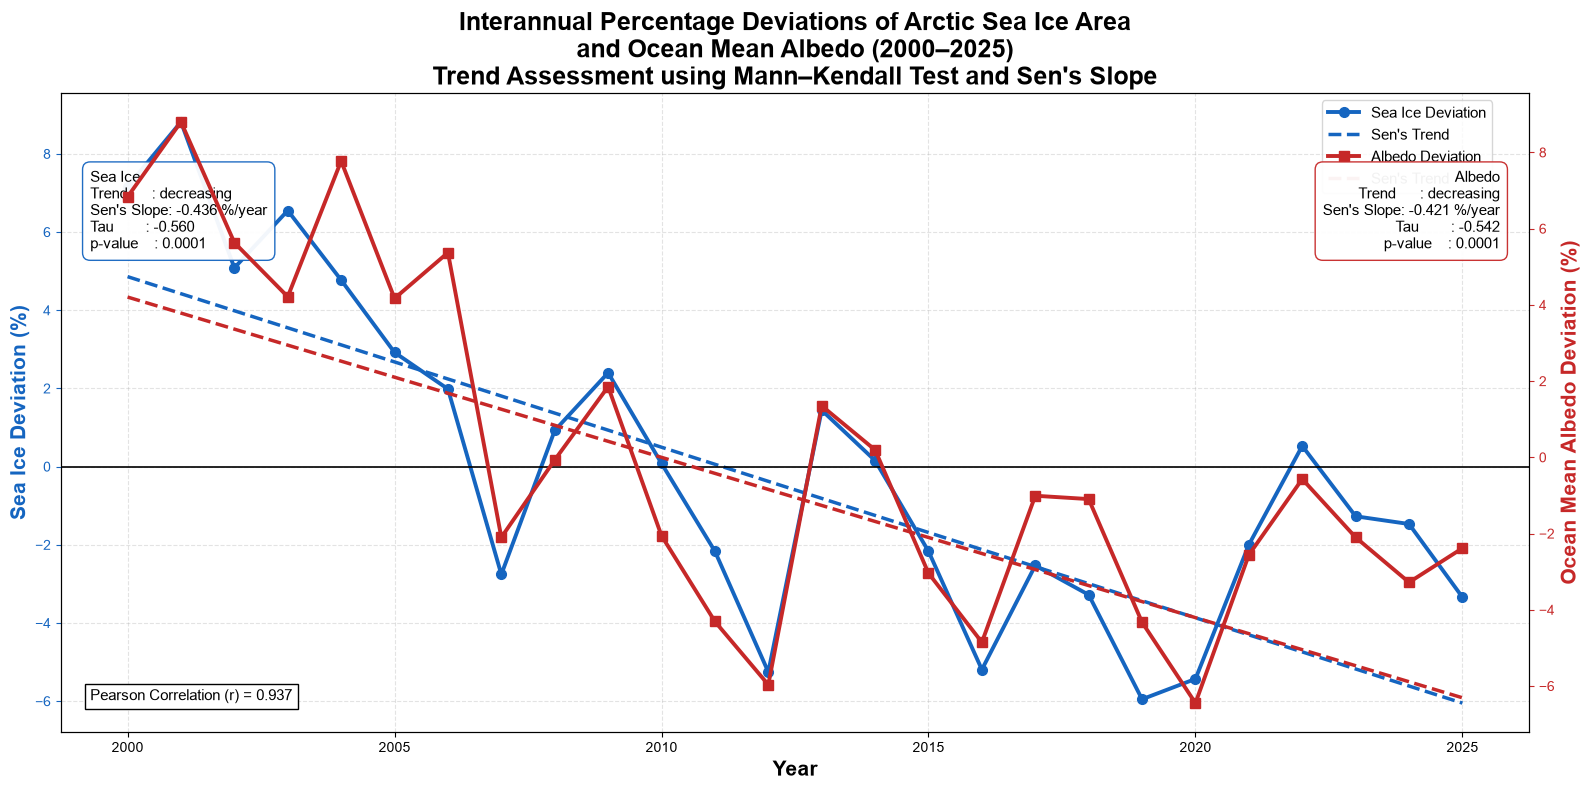


Publication Quality Figure Saved


In [ ]:
# ============================================================
# PUBLICATION QUALITY PLOT
# MK TEST + SEN'S SLOPE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN TREND LINES
# ============================================================

x = df["Year"]

index = np.arange(len(df))

sea_sen = (
    sea_result.intercept +
    sea_result.slope * index
)

alb_sen = (
    alb_result.intercept +
    alb_result.slope * index
)

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(
    df["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo (2000–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# SEA ICE INFORMATION BOX
# ============================================================

# ax1.text(
#     0.02,
#     0.96,
#     (
#         f"Sea Ice\n"
#         f"Trend : {sea_result.trend}\n"
#         f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
#         f"Tau : {sea_result.Tau:.3f}\n"
#         f"p-value : {sea_result.p:.4f}"
#     ),
#     transform=ax1.transAxes,
#     fontsize=10,
#     verticalalignment="top",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#1565C0"
#     )
# )

ax1.text(
    0.02,
    0.88,
    (
        "Sea Ice\n"
        f"Trend      : {sea_result.trend}\n"
        f"Sen's Slope: {sea_result.slope:.3f} %/year\n"
        f"Tau        : {sea_result.Tau:.3f}\n"
        f"p-value    : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=11,
    ha="left",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5",
        alpha=0.95
    )
)

# ============================================================
# ALBEDO INFORMATION BOX
# ============================================================

# ax2.text(
#     0.98,
#     0.96,
#     (
#         f"Albedo\n"
#         f"Trend : {alb_result.trend}\n"
#         f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
#         f"Tau : {alb_result.Tau:.3f}\n"
#         f"p-value : {alb_result.p:.4f}"
#     ),
#     transform=ax2.transAxes,
#     fontsize=10,
#     ha="right",
#     va="top",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#C62828"
#     )
# )

ax2.text(
    0.98,
    0.88,
    (
        "Albedo\n"
        f"Trend      : {alb_result.trend}\n"
        f"Sen's Slope: {alb_result.slope:.3f} %/year\n"
        f"Tau        : {alb_result.Tau:.3f}\n"
        f"p-value    : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=11,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5",
        alpha=0.95
    )
)

# ============================================================
# CORRELATION
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    # loc="upper right",
    loc="upper right",
    bbox_to_anchor=(0.98, 1.00),
    fontsize=11,
    frameon=True
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_PercentageDeviation.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n========================================")
print("Publication Quality Figure Saved")
print("========================================")

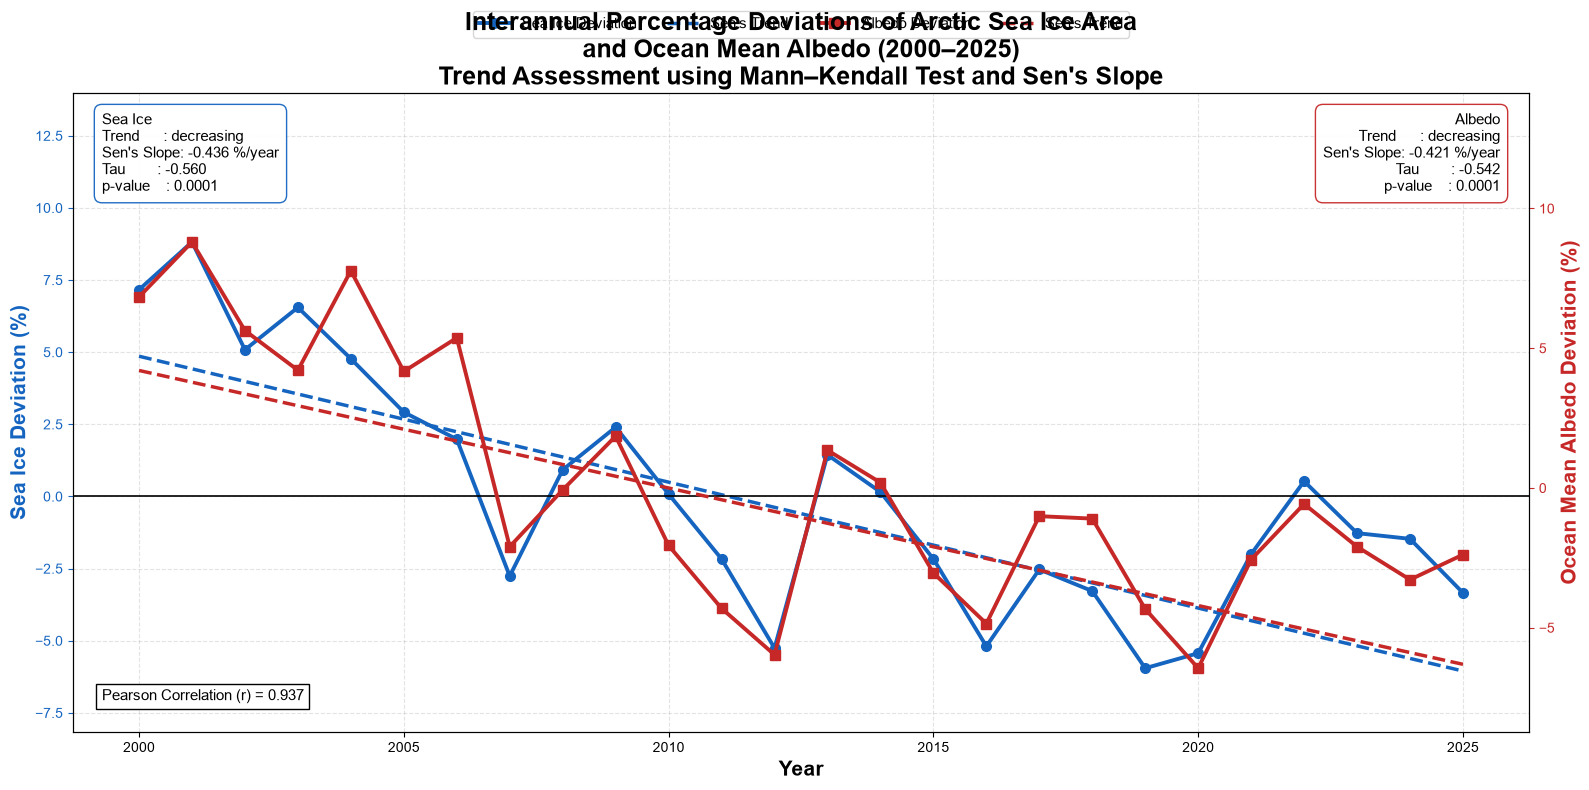


Publication Quality Figure Saved


In [ ]:
# ============================================================
# PUBLICATION QUALITY PLOT
# MK TEST + SEN'S SLOPE
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN TREND LINES
# ============================================================

x = df["Year"]

index = np.arange(len(df))

sea_sen = (
    sea_result.intercept +
    sea_result.slope * index
)

alb_sen = (
    alb_result.intercept +
    alb_result.slope * index
)

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(
    df["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo (2000–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# ADD HEADROOM SO BOXES DON'T SIT ON TOP OF THE DATA
# ============================================================

sea_min = df["Sea Ice Deviation (%)"].min()
sea_max = df["Sea Ice Deviation (%)"].max()
sea_range = sea_max - sea_min

alb_min = df["Albedo Deviation (%)"].min()
alb_max = df["Albedo Deviation (%)"].max()
alb_range = alb_max - alb_min

ax1.set_ylim(sea_min - 0.15*sea_range, sea_max + 0.35*sea_range)
ax2.set_ylim(alb_min - 0.15*alb_range, alb_max + 0.35*alb_range)

# ============================================================
# SEA ICE INFORMATION BOX
# ============================================================

ax1.text(
    0.02,
    0.97,
    (
        "Sea Ice\n"
        f"Trend      : {sea_result.trend}\n"
        f"Sen's Slope: {sea_result.slope:.3f} %/year\n"
        f"Tau        : {sea_result.Tau:.3f}\n"
        f"p-value    : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=11,
    ha="left",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5",
        alpha=0.95
    )
)

# ============================================================
# ALBEDO INFORMATION BOX
# ============================================================

ax2.text(
    0.98,
    0.97,
    (
        "Albedo\n"
        f"Trend      : {alb_result.trend}\n"
        f"Sen's Slope: {alb_result.slope:.3f} %/year\n"
        f"Tau        : {alb_result.Tau:.3f}\n"
        f"p-value    : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=11,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5",
        alpha=0.95
    )
)

# ============================================================
# CORRELATION
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# LEGEND -> MOVED ABOVE THE PLOT, BELOW THE TITLE
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
    ncol=4,
    fontsize=11,
    frameon=True
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_PercentageDeviation.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n========================================")
print("Publication Quality Figure Saved")
print("========================================")

In [45]:
print(df.columns.tolist())

['Year', 'Month', 'Sea Ice Pixels', 'Ocean Pixels', 'Ocean + Ice Pixels', 'Land Pixels', 'Coast Pixels', 'Sea Ice Area (km²)', 'Sea Ice Area (Million km²)', 'Sea Ice (%)']


In [44]:
# ============================================================
# PUBLICATION QUALITY PLOT
# MK TEST + SEN'S SLOPE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN TREND LINES
# ============================================================

x = df["Year"]

index = np.arange(len(df))

sea_sen = (
    sea_result.intercept +
    sea_result.slope * index
)

alb_sen = (
    alb_result.intercept +
    alb_result.slope * index
)

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(
    df["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo (2000–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# SEA ICE INFORMATION BOX
# ============================================================

# ax1.text(
#     0.02,
#     0.96,
#     (
#         f"Sea Ice\n"
#         f"Trend : {sea_result.trend}\n"
#         f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
#         f"Tau : {sea_result.Tau:.3f}\n"
#         f"p-value : {sea_result.p:.4f}"
#     ),
#     transform=ax1.transAxes,
#     fontsize=10,
#     verticalalignment="top",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#1565C0"
#     )
# )

# ax1.text(
#     0.02,
#     0.96,
#     (
#         "SEA ICE\n\n"
#         f"Trend        : {sea_result.trend}\n"
#         f"Sen's Slope  : {sea_result.slope:.3f} %/year\n"
#         f"Kendall Tau  : {sea_result.Tau:.3f}\n"
#         f"P-value      : {sea_result.p:.4f}"
#     ),
#     transform=ax1.transAxes,
#     fontsize=11,
#     ha="left",
#     va="top",
#     bbox=dict(
#         boxstyle="round,pad=0.6",
#         facecolor="white",
#         edgecolor="#1565C0",
#         linewidth=1.8,
#         alpha=0.97
#     )
# )

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.74,
    (
        "Sea Ice\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"p-value : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)

# ============================================================
# ALBEDO INFORMATION BOX
# ============================================================

# ax2.text(
#     0.98,
#     0.96,
#     (
#         f"Albedo\n"
#         f"Trend : {alb_result.trend}\n"
#         f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
#         f"Tau : {alb_result.Tau:.3f}\n"
#         f"p-value : {alb_result.p:.4f}"
#     ),
#     transform=ax2.transAxes,
#     fontsize=10,
#     ha="right",
#     va="top",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#C62828"
#     )
# )

# ax2.text(
#     0.985,
#     0.08,
#     (
#         "OCEAN MEAN ALBEDO\n\n"
#         f"Trend        : {alb_result.trend}\n"
#         f"Sen's Slope  : {alb_result.slope:.3f} %/year\n"
#         f"Kendall Tau  : {alb_result.Tau:.3f}\n"
#         f"P-value      : {alb_result.p:.4f}"
#     ),
#     transform=ax2.transAxes,
#     fontsize=11,
#     ha="right",
#     va="bottom",
#     bbox=dict(
#         boxstyle="round,pad=0.6",
#         facecolor="white",
#         edgecolor="#C62828",
#         linewidth=1.8,
#         alpha=0.97
#     )
# )

# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.74,
    (
        "Albedo\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"p-value : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)

# ============================================================
# CORRELATION
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# LEGEND
# ============================================================

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc="upper right",
#     fontsize=11,
#     frameon=True
# )

# ============================================================
# LEGEND (TOP RIGHT)
# ============================================================

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc="upper right",
#     bbox_to_anchor=(0.985, 0.995),
#     fontsize=11,
#     frameon=True,
#     fancybox=True,
#     framealpha=0.95,
#     edgecolor="black"
# )

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.995),
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_PercentageDeviation.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n========================================")
print("Publication Quality Figure Saved")
print("========================================")

KeyError: 'Sea Ice Deviation (%)'

# FINAL GRAPHSON NEW DATASET

C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_dataset\Yearly_Average_Sea_Ice.xlsx
   Year   March   April     May    June   July  August  September  \
0  2000  12.827  12.781  12.217  11.168  9.518   7.251      6.361   
1  2001  13.032  12.991  12.403  11.224  9.281   7.526      6.778   
2  2002  12.957  12.663  12.112  11.088  9.358   6.565      5.981   
3  2003  12.960  12.805  12.157  11.286  9.386   6.931      6.184   
4  2004  12.914  12.615  11.778  10.991  9.297   6.834      6.082   

   Yearly Mean  Minimum  Maximum  Standard Deviation  
0       10.303    6.361   12.827               2.658  
1       10.462    6.778   13.032               2.612  
2       10.103    5.981   12.957               2.880  
3       10.244    6.184   12.960               2.795  
4       10.073    6.082   12.914               2.748  


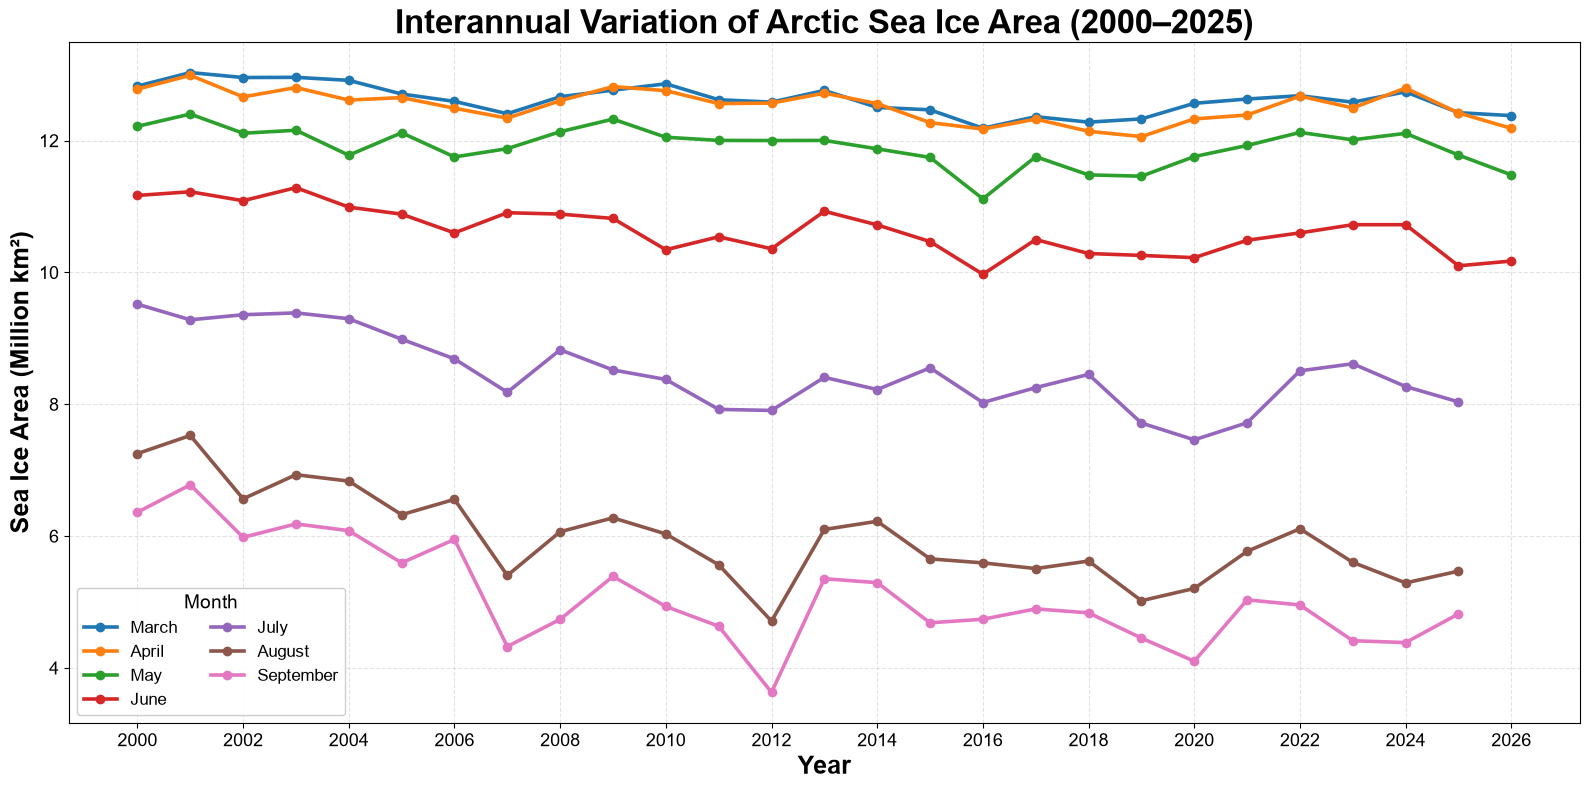


Graph Saved Successfully


In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FILE PATH
# ============================================================
import os

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

MASTER_DATASET = os.path.join(
    PROJECT,
    "Master_dataset"
)

RESULTS = os.path.join(
    PROJECT,
    "Results"
)

os.makedirs(RESULTS, exist_ok=True)


SEAICE_FILE = os.path.join(
    MASTER_DATASET,
    "Yearly_Average_Sea_Ice.xlsx"
)

print(SEAICE_FILE)

df = pd.read_excel(SEAICE_FILE)

print(df.head())
# ============================================================
# MONTHS
# ============================================================

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(
    figsize=(16,8)
)

# ============================================================
# PLOT EACH MONTH
# ============================================================

for month in months:

    ax.plot(
        df["Year"],
        df[month],
        marker="o",
        linewidth=2.6,
        markersize=6,
        label=month
    )

# ============================================================
# AXES
# ============================================================

ax.set_xlabel(
    "Year",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Sea Ice Area (Million km²)",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Interannual Variation of Arctic Sea Ice Area (2000–2025)",
    fontsize=24,
    fontweight="bold"
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

# ============================================================
# TICKS
# ============================================================

ax.tick_params(
    axis="both",
    labelsize=13
)

# Show every 2 years to avoid crowding
ax.set_xticks(df["Year"][::2])

# ============================================================
# LEGEND
# ============================================================

legend = ax.legend(
    title="Month",
    ncol=2,
    fontsize=12,
    title_fontsize=14,
    loc="lower left",
    frameon=True
)

legend.get_frame().set_alpha(0.95)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "Interannual_Monthly_Sea_Ice_Area.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n===================================")
print("Graph Saved Successfully")
print("===================================")

In [ ]:
print(MASTER_DATASET)

C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_Dataset\Sea_Ice_Master_Dataset.xlsx


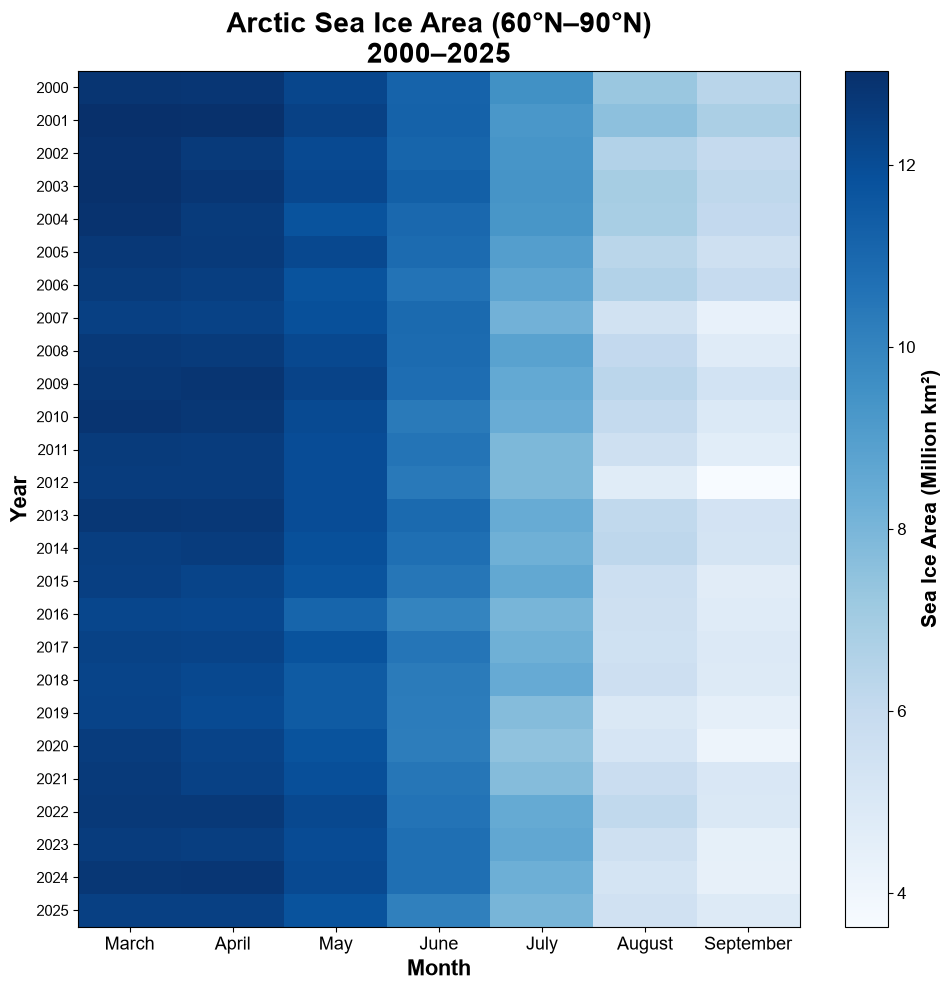


Heatmap Saved Successfully


In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FILE PATH
# ============================================================

SEAICE_FILE = os.path.join(
    MASTER_DATASET,
    "Yearly_Average_Sea_Ice.xlsx"
)



# ============================================================
# READ DATA
# ============================================================

df = pd.read_excel(SEAICE_FILE)

# ============================================================
# REMOVE 2026
# ============================================================

df = df[df["Year"] != 2026].reset_index(drop=True)

# ============================================================
# CREATE HEATMAP DATA
# ============================================================

heatmap_df = df[
    [
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September"
    ]
]

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(figsize=(10,10))

im = ax.imshow(
    heatmap_df,
    cmap="Blues",
    aspect="auto",
    interpolation="nearest"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = plt.colorbar(im)

cbar.set_label(
    "Sea Ice Area (Million km²)",
    fontsize=15,
    fontweight="bold"
)

cbar.ax.tick_params(labelsize=12)

# ============================================================
# AXES
# ============================================================

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(
    heatmap_df.columns,
    fontsize=13
)

ax.set_yticks(range(len(df["Year"])))
ax.set_yticklabels(
    df["Year"],
    fontsize=11
)

ax.set_xlabel(
    "Month",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Year",
    fontsize=16,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Arctic Sea Ice Area (60°N–90°N)\n2000–2025",
    fontsize=20,
    fontweight="bold"
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "Sea_Ice_Heatmap_New.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n======================================")
print("Heatmap Saved Successfully")
print("======================================")

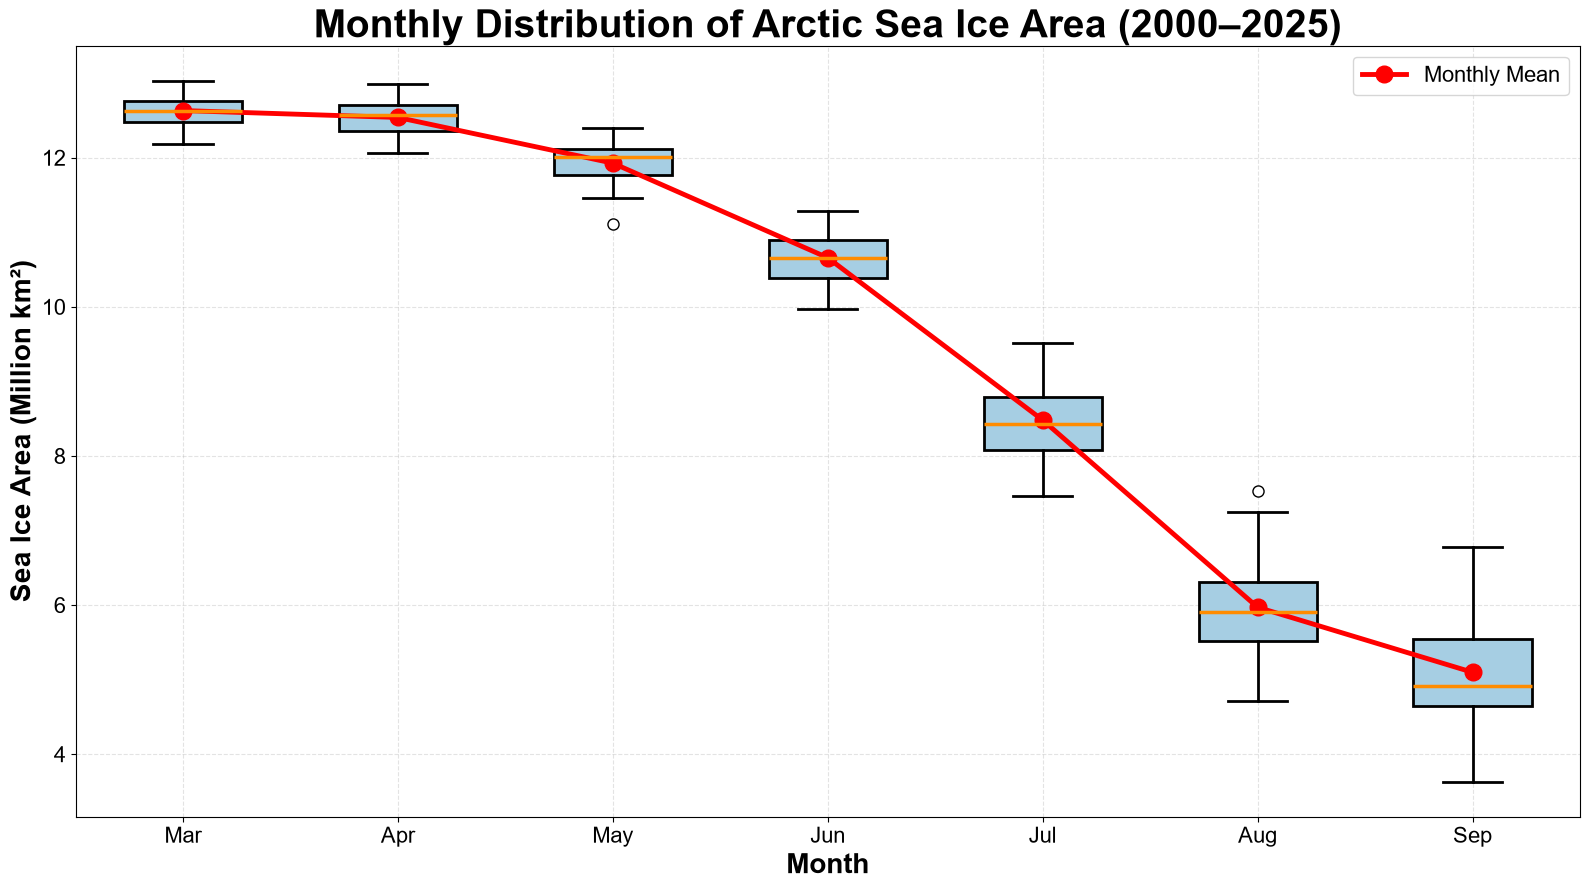


Monthly Distribution Graph Saved


In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FILE PATH
# ============================================================

SEAICE_FILE = os.path.join(
    MASTER_DATASET,
    "Yearly_Average_Sea_Ice.xlsx"
)

# ============================================================
# READ DATA
# ============================================================

df = pd.read_excel(SEAICE_FILE)

# Remove incomplete year
df = df[df["Year"] != 2026].reset_index(drop=True)

# ============================================================
# MONTHS
# ============================================================

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

# ============================================================
# DATA
# ============================================================

box_data = [df[m] for m in months]

monthly_mean = df[months].mean()

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(figsize=(16,9))

# ============================================================
# BOXPLOT
# ============================================================

bp = ax.boxplot(
    box_data,
    tick_labels=["Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"],
    patch_artist=True,
    widths=0.55
)

# ============================================================
# BOX COLORS
# ============================================================

for box in bp["boxes"]:
    box.set(
        facecolor="#A6CEE3",
        edgecolor="black",
        linewidth=2
    )

for median in bp["medians"]:
    median.set(
        color="#FF8C00",
        linewidth=2.5
    )

for whisker in bp["whiskers"]:
    whisker.set(
        color="black",
        linewidth=2
    )

for cap in bp["caps"]:
    cap.set(
        color="black",
        linewidth=2
    )

for flier in bp["fliers"]:
    flier.set(
        marker="o",
        markersize=8,
        markerfacecolor="white",
        markeredgecolor="black"
    )

# ============================================================
# MONTHLY MEAN LINE
# ============================================================

ax.plot(
    np.arange(1,8),
    monthly_mean,
    color="red",
    marker="o",
    markersize=12,
    linewidth=3.5,
    label="Monthly Mean"
)

# ============================================================
# AXES
# ============================================================

ax.set_xlabel(
    "Month",
    fontsize=20,
    fontweight="bold"
)

ax.set_ylabel(
    "Sea Ice Area (Million km²)",
    fontsize=20,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Monthly Distribution of Arctic Sea Ice Area (2000–2025)",
    fontsize=28,
    fontweight="bold"
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# TICKS
# ============================================================

ax.tick_params(
    axis="both",
    labelsize=16
)

# ============================================================
# LEGEND
# ============================================================

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "Monthly_Distribution_Sea_Ice_Area.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n===================================")
print("Monthly Distribution Graph Saved")
print("===================================")

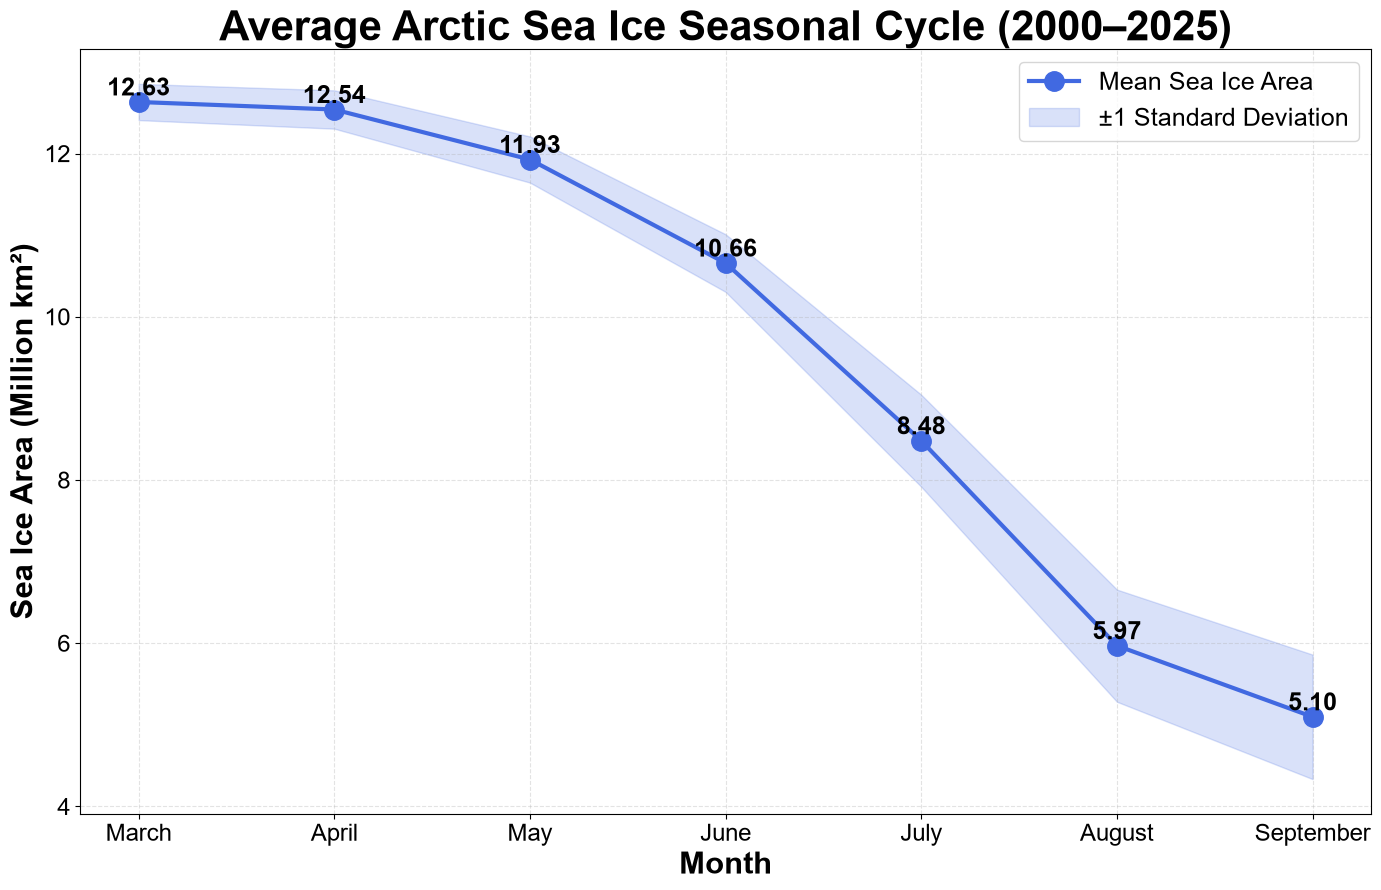

Graph Saved Successfully.


In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PATHS
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

MASTER_DATASET = os.path.join(
    PROJECT,
    "Master_dataset"
)

RESULTS = os.path.join(
    PROJECT,
    "Results"
)

SEAICE_FILE = os.path.join(
    MASTER_DATASET,
    "Yearly_Average_Sea_Ice.xlsx"
)

# ============================================================
# READ DATA
# ============================================================

df = pd.read_excel(SEAICE_FILE)

# Remove 2026 if present
df = df[df["Year"] <= 2025]

# ============================================================
# MONTHS
# ============================================================

months = [
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September"
]

# ============================================================
# CALCULATE MONTHLY STATISTICS
# ============================================================

monthly_mean = df[months].mean()

monthly_std = df[months].std()

upper = monthly_mean + monthly_std
lower = monthly_mean - monthly_std

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(14,9))

# Mean Line
plt.plot(
    months,
    monthly_mean,
    color="royalblue",
    marker="o",
    linewidth=3,
    markersize=14,
    label="Mean Sea Ice Area"
)

# Standard Deviation
plt.fill_between(
    months,
    lower,
    upper,
    color="royalblue",
    alpha=0.20,
    label="±1 Standard Deviation"
)

# ============================================================
# VALUE LABELS
# ============================================================

for x, y in zip(months, monthly_mean):

    plt.text(
        x,
        y + 0.08,
        f"{y:.2f}",
        ha="center",
        fontsize=18,
        fontweight="bold"
    )

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Average Arctic Sea Ice Seasonal Cycle (2000–2025)",
    fontsize=30,
    fontweight="bold"
)

# ============================================================
# AXES
# ============================================================

plt.xlabel(
    "Month",
    fontsize=22,
    fontweight="bold"
)

plt.ylabel(
    "Sea Ice Area (Million km²)",
    fontsize=22,
    fontweight="bold"
)

plt.xticks(fontsize=17)

plt.yticks(fontsize=17)

# ============================================================
# GRID
# ============================================================

plt.grid(
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LEGEND
# ============================================================

plt.legend(
    fontsize=18,
    loc="upper right"
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "Average_Seasonal_Cycle_Sea_Ice.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Graph Saved Successfully.")

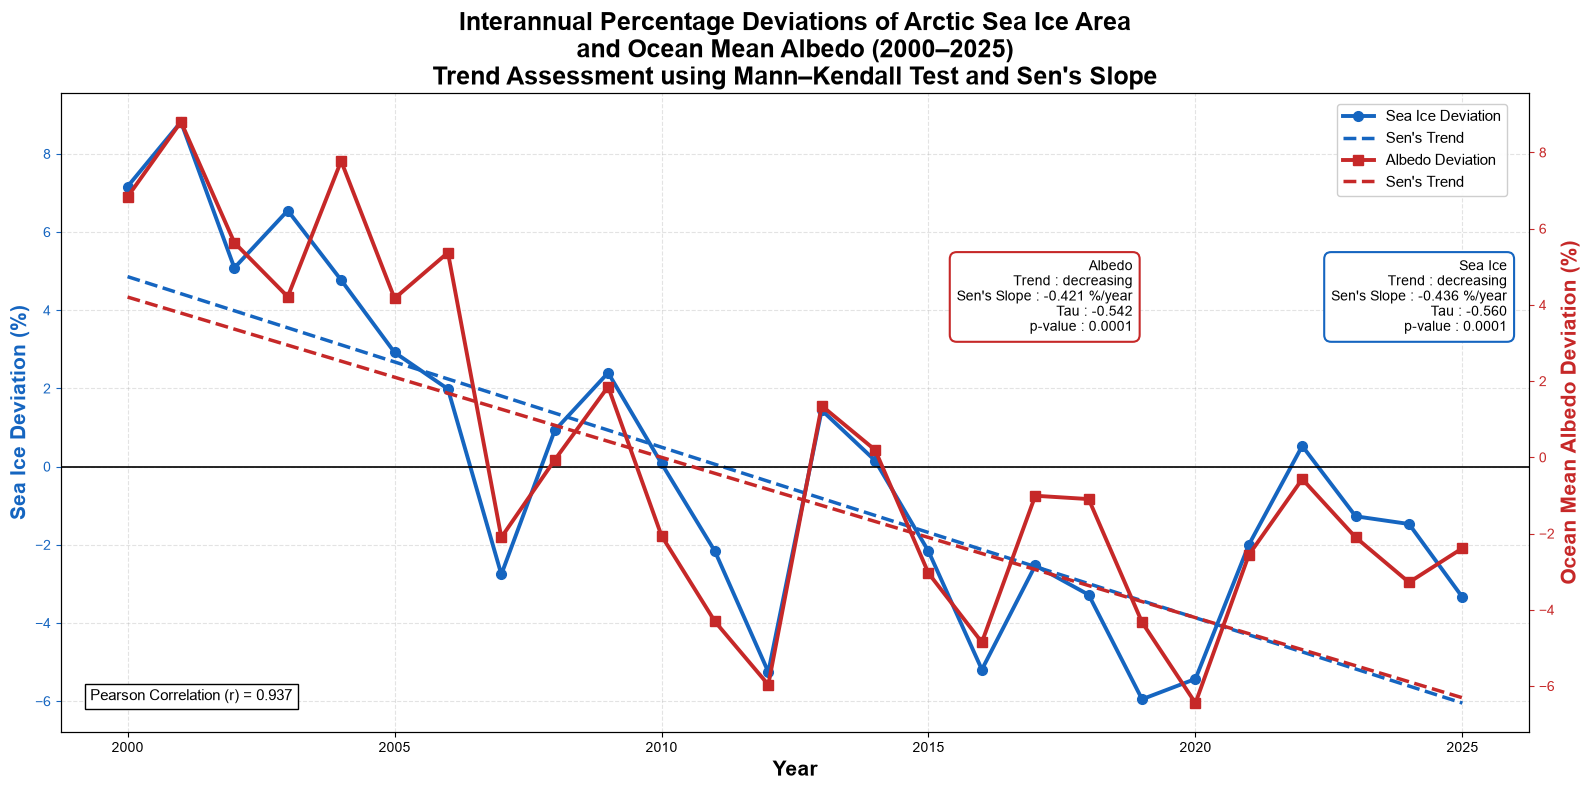


Publication Quality Figure Saved


In [59]:
# ============================================================
# PUBLICATION QUALITY PLOT
# MK TEST + SEN'S SLOPE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN TREND LINES
# ============================================================

x = df["Year"]

index = np.arange(len(df))

sea_sen = (
    sea_result.intercept +
    sea_result.slope * index
)

alb_sen = (
    alb_result.intercept +
    alb_result.slope * index
)

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(
    df["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo (2000–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# SEA ICE INFORMATION BOX
# ============================================================

# ax1.text(
#     0.02,
#     0.96,
#     (
#         f"Sea Ice\n"
#         f"Trend : {sea_result.trend}\n"
#         f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
#         f"Tau : {sea_result.Tau:.3f}\n"
#         f"p-value : {sea_result.p:.4f}"
#     ),
#     transform=ax1.transAxes,
#     fontsize=10,
#     verticalalignment="top",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#1565C0"
#     )
# )

# ax1.text(
#     0.02,
#     0.96,
#     (
#         "SEA ICE\n\n"
#         f"Trend        : {sea_result.trend}\n"
#         f"Sen's Slope  : {sea_result.slope:.3f} %/year\n"
#         f"Kendall Tau  : {sea_result.Tau:.3f}\n"
#         f"P-value      : {sea_result.p:.4f}"
#     ),
#     transform=ax1.transAxes,
#     fontsize=11,
#     ha="left",
#     va="top",
#     bbox=dict(
#         boxstyle="round,pad=0.6",
#         facecolor="white",
#         edgecolor="#1565C0",
#         linewidth=1.8,
#         alpha=0.97
#     )
# )

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.74,
    (
        "Sea Ice\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"p-value : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)

# ============================================================
# ALBEDO INFORMATION BOX
# ============================================================

# ax2.text(
#     0.98,
#     0.96,
#     (
#         f"Albedo\n"
#         f"Trend : {alb_result.trend}\n"
#         f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
#         f"Tau : {alb_result.Tau:.3f}\n"
#         f"p-value : {alb_result.p:.4f}"
#     ),
#     transform=ax2.transAxes,
#     fontsize=10,
#     ha="right",
#     va="top",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#C62828"
#     )
# )

# ax2.text(
#     0.985,
#     0.08,
#     (
#         "OCEAN MEAN ALBEDO\n\n"
#         f"Trend        : {alb_result.trend}\n"
#         f"Sen's Slope  : {alb_result.slope:.3f} %/year\n"
#         f"Kendall Tau  : {alb_result.Tau:.3f}\n"
#         f"P-value      : {alb_result.p:.4f}"
#     ),
#     transform=ax2.transAxes,
#     fontsize=11,
#     ha="right",
#     va="bottom",
#     bbox=dict(
#         boxstyle="round,pad=0.6",
#         facecolor="white",
#         edgecolor="#C62828",
#         linewidth=1.8,
#         alpha=0.97
#     )
# )

# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.74,
    (
        "Albedo\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"p-value : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)

# ============================================================
# CORRELATION
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# LEGEND
# ============================================================

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc="upper right",
#     fontsize=11,
#     frameon=True
# )

# ============================================================
# LEGEND (TOP RIGHT)
# ============================================================

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# ax1.legend(
#     lines1 + lines2,
#     labels1 + labels2,
#     loc="upper right",
#     bbox_to_anchor=(0.985, 0.995),
#     fontsize=11,
#     frameon=True,
#     fancybox=True,
#     framealpha=0.95,
#     edgecolor="black"
# )

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.995),
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_PercentageDeviation.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n========================================")
print("Publication Quality Figure Saved")
print("========================================")

In [54]:
import os

PROJECT = os.path.dirname(os.getcwd())

print(PROJECT)

c:\Users\ACER\OneDrive\Desktop\ISRO\snow_2


In [55]:
MASTER_DATASET = os.path.join(
    PROJECT,
    "Master_dataset"
)

print(MASTER_DATASET)
print(os.path.exists(MASTER_DATASET))

c:\Users\ACER\OneDrive\Desktop\ISRO\snow_2\Master_dataset
True


In [56]:
SEAICE_FILE = os.path.join(
    MASTER_DATASET,
    "Yearly_Average_Sea_Ice.xlsx"
)

ALBEDO_FILE = os.path.join(
    MASTER_DATASET,
    "Albedo_Statistics_2000_2026 (1).xlsx"
)

print(os.path.exists(SEAICE_FILE))
print(os.path.exists(ALBEDO_FILE))

True
True


In [58]:
# ============================================================
# CREATE DEVIATION DATASET
# ============================================================

import os
import pandas as pd

# ============================================================
# FILES
# ============================================================

SEAICE_FILE = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_Dataset\Yearly_Average_Sea_Ice.xlsx"

ALBEDO_FILE = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_Dataset\Albedo_Statistics_2000_2026 (1).xlsx"

# ============================================================
# READ DATA
# ============================================================

seaice = pd.read_excel(SEAICE_FILE)

albedo = pd.read_excel(
    ALBEDO_FILE,
    sheet_name="Yearly_albedo_statistics"
)

# ============================================================
# REMOVE 2026
# ============================================================

seaice = seaice[seaice["Year"] <= 2025]

albedo = albedo[albedo["Year"] <= 2025]

# ============================================================
# LONG TERM MEANS
# ============================================================

sea_mean = seaice["Yearly Mean"].mean()

alb_mean = albedo["Ocean Mean Albedo"].mean()

# ============================================================
# PERCENTAGE DEVIATION
# ============================================================

seaice["Sea Ice Deviation (%)"] = (
    (seaice["Yearly Mean"] - sea_mean)
    / sea_mean
) * 100

albedo["Albedo Deviation (%)"] = (
    (albedo["Ocean Mean Albedo"] - alb_mean)
    / alb_mean
) * 100

# ============================================================
# MERGE
# ============================================================

df = pd.merge(
    seaice[
        [
            "Year",
            "Yearly Mean",
            "Sea Ice Deviation (%)"
        ]
    ],
    albedo[
        [
            "Year",
            "Ocean Mean Albedo",
            "Albedo Deviation (%)"
        ]
    ],
    on="Year"
)

print(df.head())

   Year  Yearly Mean  Sea Ice Deviation (%)  Ocean Mean Albedo  \
0  2000       10.303               7.163631             0.4890   
1  2001       10.462               8.817423             0.4980   
2  2002       10.103               5.083390             0.4835   
3  2003       10.244               6.549960             0.4770   
4  2004       10.073               4.771353             0.4933   

   Albedo Deviation (%)  
0              6.834052  
1              8.800323  
2              5.632442  
3              4.212357  
4              7.773492  


In [50]:
print(PROJECT)
print(MASTER_DATASET)

C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Master_Dataset\Sea_Ice_Master_Dataset.xlsx


In [61]:
# ============================================================
# PATHS
# ============================================================

import os
import pandas as pd

NOTEBOOK = os.getcwd()

PROJECT = os.path.dirname(NOTEBOOK)

MASTER_DATASET = os.path.join(
    PROJECT,
    "Master_dataset"
)

RESULTS = os.path.join(
    PROJECT,
    "Results"
)

# ============================================================
# FILES
# ============================================================

SEAICE_FILE = os.path.join(
    MASTER_DATASET,
    "Yearly_Average_Sea_Ice.xlsx"
)

ALBEDO_FILE = os.path.join(
    MASTER_DATASET,
    "Albedo_Statistics_2000_2026 (1).xlsx"
)

# ============================================================
# READ DATA
# ============================================================

seaice = pd.read_excel(SEAICE_FILE)

albedo = pd.read_excel(
    ALBEDO_FILE,
    sheet_name="Yearly_albedo_statistics"
)

# ============================================================
# REMOVE 2026
# ============================================================

seaice = seaice[seaice["Year"] <= 2025].copy()

albedo = albedo[albedo["Year"] <= 2025].copy()

# ============================================================
# LONG TERM MEAN
# ============================================================

sea_mean = seaice["Yearly Mean"].mean()

alb_mean = albedo["Ocean Mean Albedo"].mean()

# ============================================================
# PERCENTAGE DEVIATION
# ============================================================

seaice["Sea Ice Deviation (%)"] = (
    (seaice["Yearly Mean"] - sea_mean)
    / sea_mean
) * 100

albedo["Albedo Deviation (%)"] = (
    (albedo["Ocean Mean Albedo"] - alb_mean)
    / alb_mean
) * 100

# ============================================================
# FINAL DATAFRAME
# ============================================================

df = pd.merge(
    seaice[
        [
            "Year",
            "Yearly Mean",
            "Sea Ice Deviation (%)"
        ]
    ],
    albedo[
        [
            "Year",
            "Ocean Mean Albedo",
            "Albedo Deviation (%)"
        ]
    ],
    on="Year"
)

print(df.head())
print(df.columns)

   Year  Yearly Mean  Sea Ice Deviation (%)  Ocean Mean Albedo  \
0  2000       10.303               7.163631             0.4890   
1  2001       10.462               8.817423             0.4980   
2  2002       10.103               5.083390             0.4835   
3  2003       10.244               6.549960             0.4770   
4  2004       10.073               4.771353             0.4933   

   Albedo Deviation (%)  
0              6.834052  
1              8.800323  
2              5.632442  
3              4.212357  
4              7.773492  
Index(['Year', 'Yearly Mean', 'Sea Ice Deviation (%)', 'Ocean Mean Albedo',
       'Albedo Deviation (%)'],
      dtype='str')


In [68]:
# ============================================================
# SELECT DATA : 2000–2015
# ============================================================

df = df[
    (df["Year"] >= 2000) &
    (df["Year"] <= 2015)
].reset_index(drop=True)

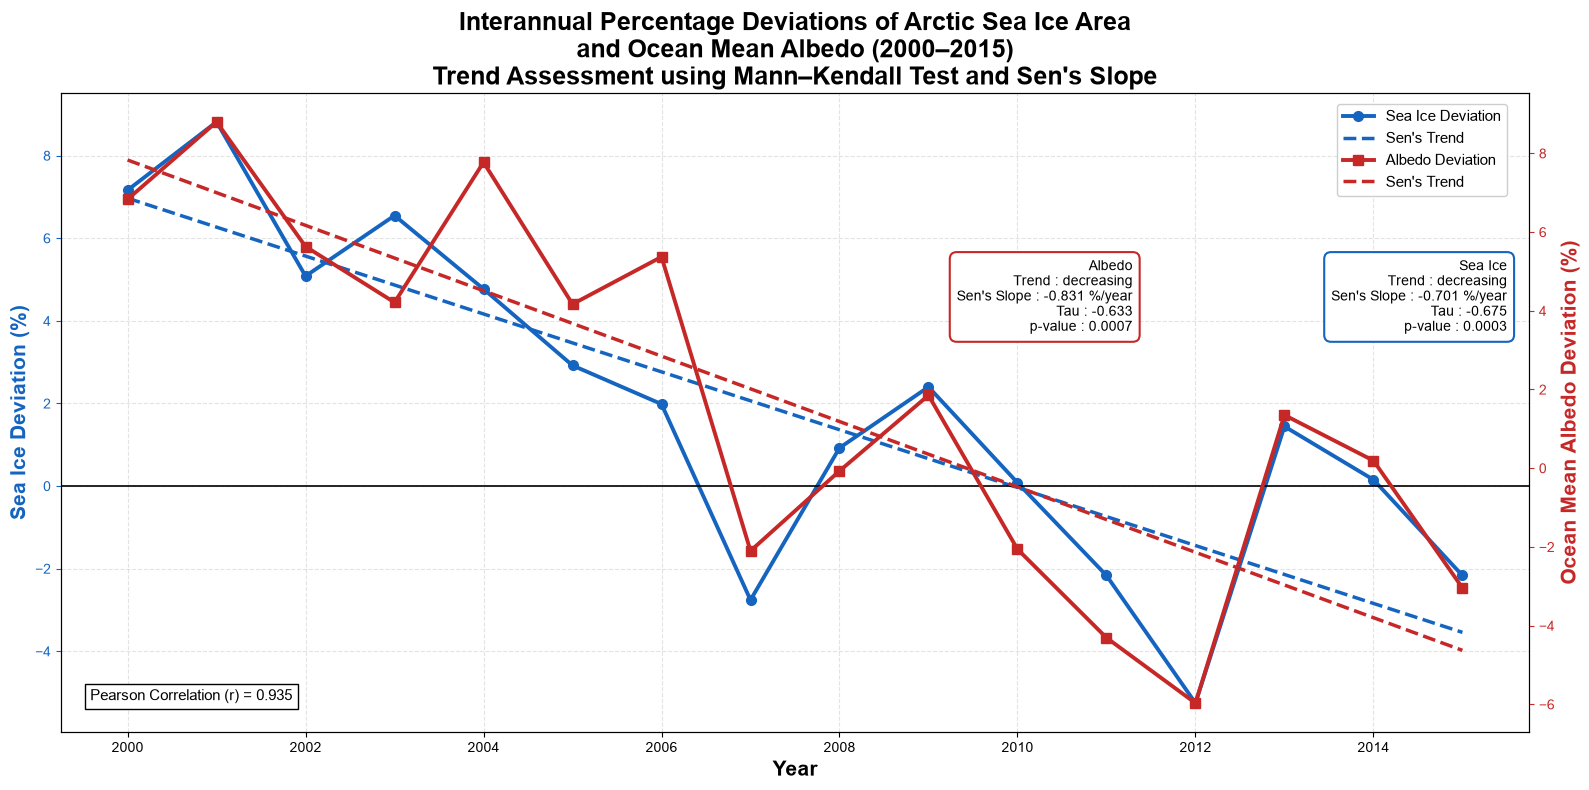


Publication Quality Figure Saved


In [69]:
# ============================================================
# PUBLICATION QUALITY PLOT
# MK TEST + SEN'S SLOPE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN TREND LINES
# ============================================================

x = df["Year"]


index = np.arange(len(df))

sea_sen = (
    sea_result.intercept +
    sea_result.slope * index
)

alb_sen = (
    alb_result.intercept +
    alb_result.slope * index
)

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(
    df["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo (2000–2015)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)
#     

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.74,
    (
        "Sea Ice\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"p-value : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)



# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.74,
    (
        "Albedo\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"p-value : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)

# ============================================================
# CORRELATION
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)



# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.995),
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_PercentageDeviation.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n========================================")
print("Publication Quality Figure Saved")
print("========================================")

In [78]:
# ============================================================
# SELECT DATA : 2016–2025
# ============================================================

df = df[
    (df["Year"] >= 2016) &
    (df["Year"] <= 2025)
].reset_index(drop=True)

In [79]:
# ============================================================
# FILTER DATA : 2016–2025
# ============================================================

df = df[(df["Year"] >= 2016) & (df["Year"] <= 2025)].copy()

print(df[["Year"]])

# Reset index (VERY IMPORTANT)
df.reset_index(drop=True, inplace=True)

    Year
0   2016
1   2016
2   2016
3   2016
4   2016
..   ...
65  2025
66  2025
67  2025
68  2025
69  2025

[70 rows x 1 columns]


In [81]:
# ============================================================
# PUBLICATION QUALITY PLOT
# MK TEST + SEN'S SLOPE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# # ============================================================
# # MANN-KENDALL TEST
# # ============================================================
# sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
# alb_result = mk.original_test(df["Albedo Deviation (%)"])

# # ============================================================
# # SEN TREND LINES
# # ============================================================

# x = df["Year"]


# index = np.arange(len(df))

# sea_sen = (
#     sea_result.intercept +
#     sea_result.slope * index
# )

# alb_sen = (
#     alb_result.intercept +
#     alb_result.slope * index
# )

# # ============================================================
# # PEARSON CORRELATION
# # ============================================================

# corr = df["Sea Ice Deviation (%)"].corr(
#     df["Albedo Deviation (%)"]
# )

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN'S TREND
# ============================================================

x = df["Year"]

index = np.arange(len(df))

sea_sen = sea_result.intercept + sea_result.slope * index
alb_sen  = alb_result.intercept + alb_result.slope * index

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(df["Albedo Deviation (%)"])

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo (2016–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)
#     

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.74,
    (
        "Sea Ice\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"p-value : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)



# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.74,
    (
        "Albedo\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"p-value : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)

# ============================================================
# CORRELATION
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)



# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.995),
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_2016_2025.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n========================================")
print("Publication Quality Figure Saved")
print("========================================")

KeyError: 'Sea Ice Deviation (%)'

In [82]:
print(df.columns.tolist())

['Year', 'Month', 'Sea Ice Pixels', 'Ocean Pixels', 'Ocean + Ice Pixels', 'Land Pixels', 'Coast Pixels', 'Sea Ice Area (km²)', 'Sea Ice Area (Million km²)', 'Sea Ice (%)']


In [73]:
print(df["Year"])

Series([], Name: Year, dtype: int64)


In [83]:
print(df.head())

print(df.columns)

   Year  Month  Sea Ice Pixels  Ocean Pixels  Ocean + Ice Pixels  Land Pixels  \
0  2016  March           19120          7766               26886        25776   
1  2016  April           19088          7798               26886        25776   
2  2016    May           17345          9541               26886        25776   
3  2016   June           15510         11376               26886        25776   
4  2016   July           12396         14490               26886        25776   

   Coast Pixels  Sea Ice Area (km²)  Sea Ice Area (Million km²)  Sea Ice (%)  
0          2850        1.218781e+07                   12.187813    71.115078  
1          2850        1.217475e+07                   12.174751    70.996057  
2          2850        1.111640e+07                   11.116403    64.513130  
3          2850        9.971780e+06                    9.971780    57.688016  
4          2850        8.026225e+06                    8.026225    46.105780  
Index(['Year', 'Month', 'Sea Ice Pixels

In [84]:
print(df.shape)
print(df.columns.tolist())

(70, 10)
['Year', 'Month', 'Sea Ice Pixels', 'Ocean Pixels', 'Ocean + Ice Pixels', 'Land Pixels', 'Coast Pixels', 'Sea Ice Area (km²)', 'Sea Ice Area (Million km²)', 'Sea Ice (%)']


In [85]:
import pandas as pd
import os

# ============================================================
# READ YEARLY SEA ICE
# ============================================================

seaice = pd.read_excel(
    SEAICE_FILE
)

# ============================================================
# READ YEARLY ALBEDO
# ============================================================

albedo = pd.read_excel(
    ALBEDO_FILE,
    sheet_name="Yearly_albedo_statistics"
)

# Remove 2026
seaice = seaice[seaice["Year"] <= 2025].copy()
albedo = albedo[albedo["Year"] <= 2025].copy()

# ============================================================
# LONG TERM MEANS
# ============================================================

sea_mean = seaice["Yearly Mean"].mean()

alb_mean = albedo["Ocean Mean Albedo"].mean()

# ============================================================
# PERCENTAGE DEVIATION
# ============================================================

seaice["Sea Ice Deviation (%)"] = (
    (seaice["Yearly Mean"] - sea_mean)
    / sea_mean
) * 100

albedo["Albedo Deviation (%)"] = (
    (albedo["Ocean Mean Albedo"] - alb_mean)
    / alb_mean
) * 100

# ============================================================
# FINAL DATAFRAME
# ============================================================

df = pd.DataFrame({
    "Year": seaice["Year"],
    "Sea Ice Deviation (%)": seaice["Sea Ice Deviation (%)"],
    "Albedo Deviation (%)": albedo["Albedo Deviation (%)"]
})

print(df.head())
print(df.columns)
print(df.shape)

   Year  Sea Ice Deviation (%)  Albedo Deviation (%)
0  2000               7.163631              6.834052
1  2001               8.817423              8.800323
2  2002               5.083390              5.632442
3  2003               6.549960              4.212357
4  2004               4.771353              7.773492
Index(['Year', 'Sea Ice Deviation (%)', 'Albedo Deviation (%)'], dtype='str')
(26, 3)


In [86]:
df = df[(df["Year"] >= 2016) & (df["Year"] <= 2025)].reset_index(drop=True)

print(df)

   Year  Sea Ice Deviation (%)  Albedo Deviation (%)
0  2016              -5.193002             -4.854336
1  2017              -2.530294             -1.009184
2  2018              -3.279180             -1.096574
3  2019              -5.952290             -4.329997
4  2020              -5.432230             -6.449200
5  2021              -1.999832             -2.560354
6  2022               0.527661             -0.572235
7  2023              -1.271748             -2.101557
8  2024              -1.469370             -3.281320
9  2025              -3.341588             -2.385574


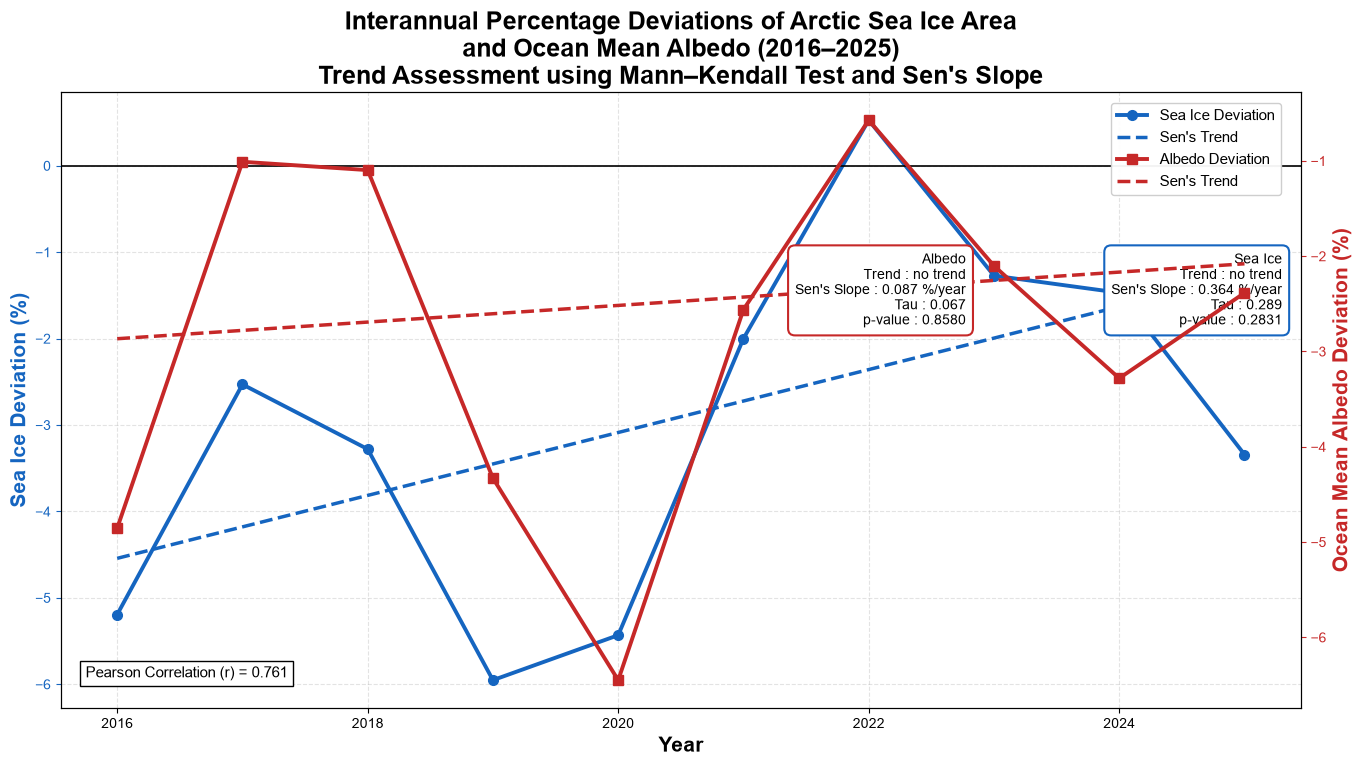


Publication Quality Figure Saved


In [87]:
# ============================================================
# PUBLICATION QUALITY PLOT
# MK TEST + SEN'S SLOPE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# # ============================================================
# # MANN-KENDALL TEST
# # ============================================================
# sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
# alb_result = mk.original_test(df["Albedo Deviation (%)"])

# # ============================================================
# # SEN TREND LINES
# # ============================================================

# x = df["Year"]


# index = np.arange(len(df))

# sea_sen = (
#     sea_result.intercept +
#     sea_result.slope * index
# )

# alb_sen = (
#     alb_result.intercept +
#     alb_result.slope * index
# )

# # ============================================================
# # PEARSON CORRELATION
# # ============================================================

# corr = df["Sea Ice Deviation (%)"].corr(
#     df["Albedo Deviation (%)"]
# )

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN'S TREND
# ============================================================

x = df["Year"]

index = np.arange(len(df))

sea_sen = sea_result.intercept + sea_result.slope * index
alb_sen  = alb_result.intercept + alb_result.slope * index

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(df["Albedo Deviation (%)"])

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.2
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area\n"
    "and Ocean Mean Albedo (2016–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)
#     

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.74,
    (
        "Sea Ice\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"p-value : {sea_result.p:.4f}"
    ),
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)



# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.74,
    (
        "Albedo\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"p-value : {alb_result.p:.4f}"
    ),
    transform=ax2.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5",
        linewidth=1.5
    )
)

# ============================================================
# CORRELATION
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)



# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.995),
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.95
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_2016_2025.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n========================================")
print("Publication Quality Figure Saved")
print("========================================")

In [1]:
# ============================================================
# INTERANNUAL VARIATION OF SEA ICE AREA & OCEAN MEAN ALBEDO
# (ACTUAL VALUES)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pymannkendall as mk

# ============================================================
# FILTER YEARS
# ============================================================

start_year = 2000
end_year = 2025

df_plot = df[
    (df["Year"] >= start_year) &
    (df["Year"] <= end_year)
].copy()

# ============================================================
# VARIABLES
# ============================================================

years = df_plot["Year"]

sea = df_plot["Yearly Mean"]

alb = df_plot["Ocean Mean Albedo"]

# ============================================================
# PEARSON CORRELATION
# ============================================================

r, p_corr = pearsonr(sea, alb)

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(sea)

alb_result = mk.original_test(alb)

# ============================================================
# SEN'S TREND LINE
# ============================================================

index = np.arange(len(df_plot))

sea_sen = sea_result.intercept + sea_result.slope * index

alb_sen = alb_result.intercept + alb_result.slope * index

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    years,
    sea,
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Area"
)

ax1.plot(
    years,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.3,
    label="Sea Ice Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Area (Million km²)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(axis="y", colors="#1565C0")

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    years,
    alb,
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Ocean Mean Albedo"
)

ax2.plot(
    years,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.3,
    label="Albedo Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(axis="y", colors="#C62828")

# ============================================================
# GRID
# ============================================================

ax1.grid(True, linestyle="--", alpha=0.35)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Variation of Arctic Sea Ice Area and Ocean Mean Albedo\n(2000–2025)",
    fontsize=18,
    fontweight="bold"
)

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# PEARSON BOX
# ============================================================

corr_p = "<0.001" if p_corr < 0.001 else f"{p_corr:.4f}"

ax1.text(
    0.02,
    0.05,
    f"Pearson r = {r:.3f}\np-value = {corr_p}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.45"
    )
)

# ============================================================
# SEA ICE BOX
# ============================================================

sea_p = "<0.001" if sea_result.p < 0.001 else f"{sea_result.p:.4f}"

ax1.text(
    0.98,
    0.08,
    f"Sea Ice\n"
    f"Trend : {sea_result.trend}\n"
    f"Sen's Slope : {sea_result.slope:.3f}\n"
    f"Tau : {sea_result.Tau:.3f}\n"
    f"p-value : {sea_p}",
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        linewidth=1.5,
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# ALBEDO BOX
# ============================================================

alb_p = "<0.001" if alb_result.p < 0.001 else f"{alb_result.p:.4f}"

ax1.text(
    0.73,
    0.08,
    f"Albedo\n"
    f"Trend : {alb_result.trend}\n"
    f"Sen's Slope : {alb_result.slope:.3f}\n"
    f"Tau : {alb_result.Tau:.3f}\n"
    f"p-value : {alb_p}",
    transform=ax1.transAxes,
    fontsize=10,
    ha="center",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        linewidth=1.5,
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    fontsize=11,
    frameon=True
)

# ============================================================
# X-TICKS
# ============================================================

ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    os.path.join(RESULTS, "Actual_SeaIce_Albedo_2000_2025.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(RESULTS, "Actual_SeaIce_Albedo_2000_2025.pdf"),
    bbox_inches="tight"
)

plt.show()

NameError: name 'df' is not defined